# The fill value, alone: `alpha` sweeps the flattened surround's weight -- `chromatin_od`, 49 ROIs x 3 clicks, post-D11

**Question.** `hem_rect_fill` keeps the 51 px `hematoxylin_od` window on the click and sets every pixel outside the
`tighten_box_otsu` rectangle to `mean(outside)` -- the mean of the pixels it discards. Under `TM_CCOEFF` that does
**not** make those pixels inert. `TM_CCOEFF` correlates `T' = T - mean(T)` against the window-centred image, so a
flat region contributes nothing only when its value equals the mean of the *final* template. Solving `f = mean(F)`
gives `f = mean(kept)`, not `mean(outside)`. This notebook varies that one number and nothing else.

## The dial

Write the fill as a blend of the two means, with `Dm = m_kept - m_outside > 0`:

```
f(alpha) = (1 - alpha) * m_kept + alpha * m_outside
```

Because `sum(I') = 0` over the window, the response separates exactly into an `alpha`-free term and a term linear
in `alpha` (verified against `cv2.matchTemplate` to float32 tolerance in Gate 6):

```
R_alpha = R_0 + alpha * Dm * sum_kept(I')
          ^^^^^^^^^^^   ^^^^^^^^^^^^^^^^^^^^^^^^^
          shape term    mass term ("OD excess inside the kept footprint")
```

So `alpha` is a single knob that mixes a **shape-matched** detector with a **mass** detector, and the four arms are
four equally spaced points on that line:

| arm | `alpha` | fill | what the ring does |
|---|---|---|---|
| `fill_alpha_m1` | -1 | `2*m_kept - m_outside` | ring `T'` **positive**: the prior is *inverted* -- it rewards a **dense** surround. A sensitivity anchor, not a candidate; see Comparisons |
| `fill_alpha_0` | 0 | `m_kept` | ring `T'` exactly 0: the response is **exactly independent** of every pixel outside the rectangle |
| `fill_alpha_1` | 1 | `m_outside` | **exactly the recorded `hem_rect_fill` template**, bit for bit |
| `fill_alpha_2` | 2 | `2*m_outside - m_kept` | the mass term doubled |

**Do not read the dial off the ring's share of `sum|T'|`.** That statistic saturates: on `300.tiff`/14499 it is
0.000 / 0.498 / 0.500 at `alpha` = 0 / 1 / 2, because as `alpha` grows the kept pixels pick up the same constant
shift and both halves of the ratio grow together. It is bounded above by 1/2 for every `alpha` by construction.
The quantity that actually measures how far apart two arms are is the **mass-to-shape ratio**,
`alpha * Dm * n_kept / sum_kept|W - m_kept|`, which on that same click is 0.00 / 2.28 / 4.55 -- it is linear in
`alpha` and unbounded. Both are recorded per click; the second is the one to read.

That ratio also restates the finding that motivated this notebook more sharply than the weight share did: at
`alpha = 1`, the recorded arm's mass term already carries **more than twice** the weight of the object's own shape.

**Note on appearance.** At `alpha = 0` the ring takes a nucleus-toned value, at `alpha = -1` a value above any
nucleus, and at `alpha = 2` one below any real background. None is a plausible image, and none needs to be:
`TM_CCOEFF` sees only `T'`, so the fill's absolute level is invisible and only its offset from the template mean
does any work. This is specific to `TM_CCOEFF` (D1). Under `TM_SQDIFF` or `TM_CCORR` the absolute level would
matter and this parameterisation would not transfer.

## Identical in all five arms

Only the fill value differs. These are the same:
- the 147 clicks, inherited from the 49-ROI joint gate, in the recorded order;
- window position (centred on the click) and template size (51 px) -- so `blank_seed_square` blanks the **same**
  51x51 square in every arm, and this design carries none of the base-size/blank-square confound that
  `bbox_refinement_three_way` had;
- the kept rectangle, asserted equal to the recorded `hem_rect_fill` rectangle on every click;
- search image (`hematoxylin_od`, D11-blanked then replicate-padded by 25 px);
- peak, NMS and seed settings (`PEAK_MIN_DISTANCE` 7, `DEEP_FLOOR_Z` -1.5, `MAX_PEAKS` 100,
  NMS radius = match radius = 7.5 um, D11 `blank_seed_square` at the click, base_size 51);
- the `chromatin_od` window (51 px), scored against the **unblanked** channel;
- scoring (greedy centre-distance match at 7.5 um, with the click's own annotation removed from the ground truth).

**Why the tight rectangle and not the +1 um one.** Because `alpha = 1` on the tight rectangle reproduces a recorded
run *bit for bit*, which is what makes Gate 1 possible. It is **not** because the tight rectangle gives the dial
more range -- it does not. The dial's range is set by `alpha`, which is unbounded either way; the +1 um rectangle
would work equally well as a family, and is the obvious second family if this one moves.

## This run is post-D11; the recorded fill runs are not

D11 (`9e22eb9`) replaced the 5 px post-NMS self-hit filter with `blank_seed_square`, and `production.SELF_HIT_RADIUS`
no longer exists. The recorded `hemrectfill` and `hemrectfill1um` runs are **pre-D11** and cannot be reproduced by
current code. `bbox_refinement_three_way` has been re-run post-D11 (`0af7ff1`), so `default_51` *can* be gated.

D11 changes the outcome -- `default_51` TP@30 goes from 1910 to 1914 over the 147 clicks -- but **not** the
templates: the recorded `default_51` template SHA-1s are identical pre- and post-D11 on all 147 clicks, because D11
touches only the search channel. So "keep every template the same" is verifiable here, and is verified (Gate 4).

The consequence, stated before reading anything: `fill_alpha_1 - default_51` measured here will **not** equal the
recorded pre-D11 `+0.20 / +0.48 / +0.93` points. That difference is D11, not the fill value, and it is reported in
its own table rather than folded into a result.

## Gates, all before any statistic is read

1. **Harness fidelity (pre-D11, subset).** On the first 2 ROIs x 3 clicks, the inlined pipeline run in *pre-D11
   mode* (no blanking, 5 px post-NMS self-hit filter) must reproduce the recorded `bbox3way` `default_51` and
   `hemrectfill` `hem_rect_fill` runs bit for bit. This proves the reimplementation is faithful before the D11
   switch is flipped.
2. **Production-path equivalence (post-D11, subset).** On the same subset, the inlined pipeline with the
   `default_51` template must equal `production.run_production_pipeline(rank_key="chromatin_od")` row for row.
3. **Post-D11 parity (full run).** `default_51` must reproduce the recorded `bbox3way_postD11` run on all 147
   clicks: `n_peaks`, `n_detections`, `n_blanked_px`, TP@10/20/30, template SHA-1, and the top-30
   rank/cx/cy/bucket/matched_ann_id/score/od.
4. **Templates unchanged (full run).** `default_51` and `fill_alpha_1` template SHA-1s must equal the recorded
   ones, the kept rectangle must equal the recorded one, `fill_alpha_1`'s fill value must equal the recorded
   `fill_value`, and the five arms' templates must be pairwise distinct on every click.
5. **The dial is a dial (full run).** `fill_alpha_0`'s ring must carry `< 1e-5` of the template's total `sum|T'|`,
   the signed mass-to-shape ratio must be strictly increasing in `alpha`, and the ring's weight share must stay at
   or below 1/2.
6. **The identity.** `TM_CCOEFF(I, F_alpha_0)` must equal a plain `TM_CCORR` of the kept-region-only `T'` kernel
   against `I`, and `R_alpha` must equal `R_0 + alpha * Dm * sum_kept(I')` for every arm.
7. **The arms produce different candidate lists (full run, report-only).** Template distinctness is not detection
   distinctness: `MAX_PEAKS` binds at 100 on every arm and `chromatin_od` re-ranks afterwards, so the top-30 lists
   could in principle wash out the template difference. The per-arm top-30 overlap with `fill_alpha_1` and with
   `default_51` is reported, so a wash-out is visible rather than silent.

## Comparisons, fixed before the run

Every delta is `a - b`, the unit is the ROI (49), and a ROI's delta at K is its TP@K summed over its 3 clicks.

- **Primary family (6 tests, Holm within):**
  - `fill_alpha_0 - fill_alpha_1` -- the direct test of the recorded arm's fill value, the question that prompted
    this notebook.
  - `fill_alpha_2 - fill_alpha_0` -- the widest contrast *inside the region anyone would ship*, and the
    best-powered test of "does the surround's weight change precision at all".
- **Secondary family, against the recorded arm (6 tests, Holm within):** `fill_alpha_m1 - fill_alpha_1` and
  `fill_alpha_2 - fill_alpha_1`.
- **Secondary family, against the incumbent (12 tests, Holm within):** each of the four fill arms minus
  `default_51`.
- **Trend (3 tests, Holm within), reported separately in TP units, not precision points:** the per-ROI linear
  contrast with weights `(-1, 0, +1)` across `alpha = (0, 1, 2)`. This is the highest-powered read of a monotone
  dose-response in the informative region, and it is the one to look at first if no individual pair resolves.

**`alpha = -1` is a sensitivity anchor, not a candidate, and it is deliberately kept out of both the primary
family and the tested trend.** Inverting the prior is expected to be much worse, so a contrast that includes it
would report a "monotone trend in alpha" driven entirely by an arm nobody would ship. What it is for is the
opposite inference: if `alpha = -1` moves precision a long way, the measurement demonstrably has leverage over
the fill value, and a null across `alpha = 0, 1, 2` then means "the plausible region is flat" rather than
"this design cannot see the fill value at all". A four-level contrast is still printed alongside the tested one,
labelled descriptive, so the anchor is visible without being read as evidence about the question.

Per pair and K: the pooled precision delta with a cluster bootstrap 95% CI over ROIs (`BOOT_SEED` 20260917 and the
same ROI order as the `hemrectfill` runs, asserted, so the resampled ROI sets are the same ones), a t interval over
the ROI-level deltas, ROI-level W/L/T, an exact sign-flip p by convolution, Holm within the family, and the D5 bar
(bootstrap CI excludes 0 **and** a majority of all 49 ROIs move in the delta's direction).

**Reading rules, fixed before the run.** Applied to the bootstrap CI of each delta at each K.
- **CI excludes 0, delta < 0:** `a` has lower precision than `b`.
- **CI excludes 0, delta > 0:** `a` has higher precision than `b`.
- **CI includes 0:** no difference detected. The CI is quoted as the bound. No equivalence is claimed.

Each verdict is stated with its t CI, exact p, Holm p, ROI W/L/T and D5 bar alongside -- never a CI on its own.

**What each outcome would mean, written down now so it cannot be chosen afterwards.**
- *Nothing separates at K = 20/30 anywhere on the dial, trend included:* the flattened surround's weight does not
  matter at `chromatin_od`. Since `hem_rect_fill` already sits on `default_51`, the template's surround does not
  matter either, and the surround-fill direction closes -- including the hybrid keep-region work, which would be
  asking a 1-2 px rectangle change to move a dial measured flat over its whole range.
- *Precision falls as `alpha` rises:* the recorded arm was diluting the object's own signal with a mass term. The
  right template is the object alone (`alpha = 0`), and the keep-region's shape then becomes worth refining.
- *Precision rises with `alpha`:* the isolation prior is doing real work and the original hypothesis holds.
  `alpha` becomes a knob to tune -- but see the caveat below on what a large-`alpha` gain would actually be.
- *Precision peaks at `alpha = 0`* -- that is, `alpha_0 - alpha_1` positive **and** `alpha_2 - alpha_0` negative:
  some surround weight is worse than none in either direction, and `alpha = 0` is the right template.

**The trend contrast tests monotonicity, and only that.** A peak at `alpha = 0` would make the `(-1, 0, +1)`
contrast average a rise against a fall and report roughly nothing, so a flat trend p must **not** be written up as
"the dial does nothing". The read for a peak is the three pooled precisions plus the two primary pairwise
contrasts, whose joint signature is named in the bullet above. Check the pooled dose-response before the trend p,
not after.

**Ties bound what can be shown.** Precision@K moves in steps of `1/(3K)` per ROI, so ROI-level deltas tie often:
the recorded `hem_rect_fill_1um - hem_rect_fill` pair tied on 39/49 ROIs at K = 10 and 25/49 at K = 30, and
`alpha_0 - alpha_1` is a within-fill contrast on a shared keep-region, so it is likely the most tie-heavy pair
here. The exact sign-flip p cannot fall below `2 ** (1 - n_nonzero)`, so a pair with few nonzero ROIs cannot reach
significance at any effect size. `n_nonzero` and `min_attainable_p` are printed beside every verdict, and any row
whose Holm-adjusted floor exceeds 0.05 is flagged: such a row bounds nothing and is not a null.

## Caveats

- `chromatin_od` ranking only. Do not read across to `tm_score`.
- The 147 clicks are inherited from the 49-ROI joint gate, so every click is one where **both** Otsu gates accept.
  `alpha` is undefined without a hematoxylin rectangle, so conditioning on the hem gate is intrinsic to the
  question; conditioning on the *gray* gate is not, and is inherited baggage.
- One keep-region and four points on the dial.
- `alpha`'s effective weight is `alpha * Dm`, and `Dm` varies per click, so `alpha` is not a dimensionless weight
  with the same meaning everywhere. The induced mass-to-shape ratio is recorded per click.
- As `alpha` grows the mass term approaches "integrated OD inside a fixed footprint", which is close to what the
  `chromatin_od` ranker itself measures. A gain at `alpha = 2` would partly be candidate generation converging on
  the ranking axis rather than a better template. `alpha = 2` is a probe, not a production candidate; `alpha = -1`
  is a probe too, and exists to bracket `alpha = 0` so a monotone trend can be distinguished from a peak.
- **Power.** The recorded ROI-level bootstrap CIs at K = 30 are about +/-1 point for an arm-vs-`default_51`
  contrast. `alpha = 0` vs `alpha = 1` removes a mass term worth 2.3x the object's own shape weight, a far larger
  perturbation than the 4 px margin that resolved flat, so more movement is expected -- but effects below about
  1 point at K = 20/30 will not resolve, and no equivalence is claimed.

In [1]:
import gc
import hashlib
import itertools
import math
import os
import sys
import time
import types

import cv2
import numpy as np
import pandas as pd
from fractions import Fraction
from scipy import stats as sps
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import chromatin as cm
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import invariants as inv
from midog_utils import production as prod
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance

pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 400)
pd.set_option('display.max_colwidth', 140)

NB_T0 = time.time()

# Production settings, read from midog_utils and checked against the values the recorded runs used.
# SELF_HIT_RADIUS is deliberately absent: D11 removed it, and its absence is asserted below.
REFERENCE_CONFIG = dict(CHANNEL='hematoxylin_od', TM_METHOD=cv2.TM_CCOEFF, PEAK_MIN_DISTANCE=7, DEEP_FLOOR_Z=-1.5, MAX_PEAKS=100, OD_WINDOW=51)
CONFIG_DRIFT = pd.DataFrame([dict(setting=k, production_py=getattr(prod, k), reference_notebook=v, match=getattr(prod, k) == v) for k, v in REFERENCE_CONFIG.items()])
print(CONFIG_DRIFT.to_string(index=False))
assert CONFIG_DRIFT['match'].all(), 'midog_utils.production no longer matches the configuration the recorded runs used'
assert ev.MIDOG_RADIUS_UM == 7.5, 'D7: NMS radius = match radius = 7.5 um'
assert tm.BASE_SIZE == 51, 'the template size this notebook hard-codes is 51 px'
assert tm.PATCH_SIZE == 73, 'the rotation-safe patch this notebook hard-codes is 73 px'
assert prod.OD_WINDOW // 2 == 25, 'the replicate pad this notebook hard-codes is 25 px'
assert hasattr(tm, 'blank_seed_square'), 'D11 has not been applied: template_match.blank_seed_square is missing'
assert not hasattr(prod, 'SELF_HIT_RADIUS'), 'production.SELF_HIT_RADIUS still exists, so this is not post-D11 code'

SMOKE_ROIS = None            # None = all 49 ROIs; a smoke run names a few ROI file names
PRE_D11_SELF_HIT_RADIUS = 5.0  # the constant D11 deleted, kept only to replay the pre-D11 gate
PAD = prod.OD_WINDOW // 2      # 25
BASE_SIZE = tm.BASE_SIZE       # 51

ARM_ALPHA = {'fill_alpha_m1': -1.0, 'fill_alpha_0': 0.0, 'fill_alpha_1': 1.0, 'fill_alpha_2': 2.0}
FILL_ARMS = tuple(ARM_ALPHA)
ARMS = ('default_51',) + FILL_ARMS
RECORDED_ALPHA1_ARM = 'fill_alpha_1'  # bit-identical to the recorded hem_rect_fill template
# Two linear contrasts. Only the first is a test of the question: alpha = -1 inverts the prior and is expected to
# be badly worse, so a four-level contrast that includes it would report a "monotone trend" driven entirely by an
# arm nobody would ship. The four-level one is kept as a sensitivity anchor and is never Holm-corrected or read as
# evidence about the fill value.
TRENDS = {
    'trend_alpha_0_1_2': dict(arms=('fill_alpha_0', 'fill_alpha_1', 'fill_alpha_2'), weights=(-1, 0, 1), tested=True, note='the informative region: does precision move as the surround weight grows from zero?'),
    'anchor_all_4_levels': dict(arms=FILL_ARMS, weights=(-3, -1, 1, 3), tested=False, note='descriptive only -- dominated by alpha=-1, which is a sensitivity anchor, not a level anyone would ship'),
}
for name, spec in TRENDS.items():
    assert sum(spec['weights']) == 0 and len(spec['weights']) == len(spec['arms']), f'{name}: the weights must be a zero-sum contrast, one per arm'
    assert np.allclose(np.diff([ARM_ALPHA[a] for a in spec['arms']]), 1.0), f'{name}: a linear contrast assumes equally spaced alpha levels'
    assert sum(w * ARM_ALPHA[a] for w, a in zip(spec['weights'], spec['arms'])) != 0, f'{name}: the contrast is orthogonal to alpha, so it cannot estimate a slope'

FAMILIES = {
    'primary_6': (('fill_alpha_0', 'fill_alpha_1'), ('fill_alpha_2', 'fill_alpha_0')),
    'secondary_vs_alpha1_6': (('fill_alpha_m1', 'fill_alpha_1'), ('fill_alpha_2', 'fill_alpha_1')),
    'secondary_vs_default_12': tuple((arm, 'default_51') for arm in FILL_ARMS),
}
PAIRS = tuple(pair for pairs in FAMILIES.values() for pair in pairs)  # every delta is a - b
PAIR_FAMILY = {f'{a} - {b}': family for family, pairs in FAMILIES.items() for a, b in pairs}
assert len(PAIR_FAMILY) == len(PAIRS), 'a pair appears in two families'

BUDGETS = (10, 20, 30)
SEED_INDICES = (0, 1, 2)
N_BOOT = 10_000
BOOT_SEED = 20260917  # the hemrectfill runs' seed; with the same ROI order the resampled ROI sets are the same ones
B3 = '../results/precision_at_k_49roi_3seed_chromatin_bbox3way'
B3P = f'{B3}_postD11'
HRF = '../results/precision_at_k_49roi_3seed_chromatin_hemrectfill'
SUBSET_DIRS = {'original_14': '../images/extra_valid', 'testing_35': '../images/extra_valid/testing_set'}
INSPECT_ROI = '300.tiff'  # the ROI whose templates are rendered panel by panel
N_GATE_ROIS = 2           # ROIs used by the pre-D11 fidelity gate and the production-path gate

SUFFIX = '' if SMOKE_ROIS is None else '_smoke'
OUT_STEM = f'../results/precision_at_k_49roi_3seed_chromatin_fillalpha_postD11{SUFFIX}'
OUT = {name: f'{OUT_STEM}_{name}.csv' for name in ('clicks', 'per_run', 'top30', 'per_roi', 'delta_per_roi', 'delta_stats', 'trend_stats', 'verification', 'd11_remeasurement')}
FIG_PATHS = {name: f'fillalpha_{name}{SUFFIX}.png' for name in ('inspect_templates', 'surround_weight', 'precision')}
RECORDED_STEMS = (B3, B3P, HRF, f'{HRF}1um', '../results/precision_at_k_14roi_')
assert not any(p.startswith(stem) for p in OUT.values() for stem in RECORDED_STEMS), 'an output path would overwrite a recorded run'

# Okabe-Ito, the published colourblind-safe qualitative set; fixed order, one hue per arm, never cycled.
ARM_COLOR = {'default_51': '#666666', 'fill_alpha_m1': '#CC79A7', 'fill_alpha_0': '#0072B2', 'fill_alpha_1': '#E69F00', 'fill_alpha_2': '#009E73'}

print(f"\narms {ARMS}; alpha {tuple(ARM_ALPHA.values())}; K = {BUDGETS}; cluster bootstrap B = {N_BOOT} (seed {BOOT_SEED}); smoke ROIs = {SMOKE_ROIS}")
for family, pairs in FAMILIES.items():
    print(f"  {family}: {[f'{a} - {b}' for a, b in pairs]}")
for name, spec in TRENDS.items():
    print(f"  {name} ({'tested, Holm over 3' if spec['tested'] else 'descriptive only'}): weights {spec['weights']} over alpha {tuple(ARM_ALPHA[a] for a in spec['arms'])}")
print('outputs:', *OUT.values(), *FIG_PATHS.values(), sep='\n  ')

          setting  production_py reference_notebook  match
          CHANNEL hematoxylin_od     hematoxylin_od   True
        TM_METHOD              4                  4   True
PEAK_MIN_DISTANCE              7                  7   True
     DEEP_FLOOR_Z           -1.5               -1.5   True
        MAX_PEAKS            100                100   True
        OD_WINDOW             51                 51   True

arms ('default_51', 'fill_alpha_m1', 'fill_alpha_0', 'fill_alpha_1', 'fill_alpha_2'); alpha (-1.0, 0.0, 1.0, 2.0); K = (10, 20, 30); cluster bootstrap B = 10000 (seed 20260917); smoke ROIs = None
  primary_6: ['fill_alpha_0 - fill_alpha_1', 'fill_alpha_2 - fill_alpha_0']
  secondary_vs_alpha1_6: ['fill_alpha_m1 - fill_alpha_1', 'fill_alpha_2 - fill_alpha_1']
  secondary_vs_default_12: ['fill_alpha_m1 - default_51', 'fill_alpha_0 - default_51', 'fill_alpha_1 - default_51', 'fill_alpha_2 - default_51']
  trend_alpha_0_1_2 (tested, Holm over 3): weights (-1, 0, 1) over alpha (0.0, 1

In [2]:
# Recorded runs this notebook reads. default_51 is gated against the post-D11 bbox3way re-run; the pre-D11
# bbox3way and hemrectfill runs are read for the harness-fidelity gate and for the template SHA-1s and rectangles.
B3P_RUN = pd.read_csv(f'{B3P}_per_run.csv', float_precision='round_trip')
B3P_TOP = pd.read_csv(f'{B3P}_top30.csv', float_precision='round_trip')
B3_RUN = pd.read_csv(f'{B3}_per_run.csv', float_precision='round_trip')
B3_TOP = pd.read_csv(f'{B3}_top30.csv', float_precision='round_trip')
HRF_RUN = pd.read_csv(f'{HRF}_per_run.csv', float_precision='round_trip')
HRF_TOP = pd.read_csv(f'{HRF}_top30.csv', float_precision='round_trip')
HRF_CLICKS = pd.read_csv(f'{HRF}_clicks.csv', float_precision='round_trip')
HRF_STATS = pd.read_csv(f'{HRF}_delta_stats.csv', float_precision='round_trip')
assert (len(B3P_RUN), len(B3P_TOP), len(B3_RUN), len(HRF_RUN), len(HRF_CLICKS)) == (441, 13230, 441, 294, 147), 'a recorded input does not have its expected row count'

# post-D11 default_51: the parity target for this run's own default_51 arm
POST_RUN = B3P_RUN[B3P_RUN['condition'] == 'default_51'].set_index(['file_name', 'seed_index']).sort_index()
POST_TOP = {key: g for key, g in B3P_TOP[B3P_TOP['condition'] == 'default_51'].groupby(['file_name', 'seed_index'])}
assert POST_RUN.index.is_unique and len(POST_RUN) == 147 and len(POST_TOP) == 147, 'post-D11 default_51 is not one row and one top-30 list per click'
assert all(len(g) == 30 for g in POST_TOP.values()), 'a post-D11 top-30 list does not have 30 rows'

# pre-D11 references, used only by the harness-fidelity gate
PRE_RUN = pd.concat([B3_RUN[B3_RUN['condition'] == 'default_51'], HRF_RUN[HRF_RUN['condition'] == 'hem_rect_fill']]).set_index(['file_name', 'seed_index', 'condition']).sort_index()
PRE_TOP = {key: g for key, g in pd.concat([B3_TOP[B3_TOP['condition'] == 'default_51'], HRF_TOP[HRF_TOP['condition'] == 'hem_rect_fill']]).groupby(['file_name', 'seed_index', 'condition'])}
PRE_ARM_OF = {'default_51': 'default_51', RECORDED_ALPHA1_ARM: 'hem_rect_fill'}  # this notebook's arm -> the recorded arm it replays
assert len(PRE_RUN) == 294 and len(PRE_TOP) == 294, 'pre-D11 references are not one row per click per replayed arm'

# the clicks: the recorded post-D11 default_51 rows in CSV order, carrying the recorded rectangle and fill value
CLICKS = B3P_RUN[B3P_RUN['condition'] == 'default_51'].reset_index(drop=True)
rect_rec = HRF_CLICKS[['file_name', 'seed_index', 'rect_y0', 'rect_y1', 'rect_x0', 'rect_x1', 'fill_value', 'n_filled_px']].rename(columns={'rect_y0': 'rec_y0', 'rect_y1': 'rec_y1', 'rect_x0': 'rec_x0', 'rect_x1': 'rec_x1', 'fill_value': 'rec_fill_value', 'n_filled_px': 'rec_n_filled_px'})
pre_sha = HRF_RUN.loc[HRF_RUN['condition'] == 'hem_rect_fill', ['file_name', 'seed_index', 'tpl_sha1']].rename(columns={'tpl_sha1': 'rec_alpha1_sha1'})
click_keys = list(zip(CLICKS['file_name'], CLICKS['seed_index']))
CLICKS = CLICKS.merge(rect_rec, on=['file_name', 'seed_index'], how='left', validate='one_to_one').merge(pre_sha, on=['file_name', 'seed_index'], how='left', validate='one_to_one')
assert list(zip(CLICKS['file_name'], CLICKS['seed_index'])) == click_keys, 'a merge changed the click rows or their order'
assert CLICKS[['rec_y0', 'rec_y1', 'rec_x0', 'rec_x1', 'rec_fill_value', 'rec_alpha1_sha1']].notna().all().all(), 'a click has no recorded fill geometry'

# the bootstrap reuses BOOT_SEED, which only means "the same resampled ROI sets" if the ROI order also matches
assert list(pd.unique(CLICKS['file_name'])) == list(pd.unique(HRF_RUN['file_name'])), 'the ROI order differs from the hemrectfill run, so reusing BOOT_SEED would not resample the same ROI sets'
assert list(pd.unique(CLICKS['file_name'])) == list(pd.unique(B3_RUN['file_name'])), 'the ROI order differs from the bbox3way run'

# D11 changes detections but not templates: the same click's default_51 template SHA-1 is identical pre and post
pre_default = B3_RUN[B3_RUN['condition'] == 'default_51'].reset_index(drop=True)
assert pre_default[['file_name', 'seed_index']].equals(CLICKS[['file_name', 'seed_index']]), 'the pre-D11 and post-D11 bbox3way runs do not list the clicks in the same order'
assert (pre_default['tpl_sha1'].to_numpy() == CLICKS['tpl_sha1'].to_numpy()).all(), 'D11 changed a default_51 template, which it must not'
print(f"D11 left every default_51 template unchanged (147/147 SHA-1 equal) but changed detections: TP@30 {int(pre_default['tp_at_30'].sum())} -> {int(CLICKS['tp_at_30'].sum())}")

ROI_ORDER = [fn for fn in pd.unique(CLICKS['file_name']) if SMOKE_ROIS is None or fn in SMOKE_ROIS]
assert SMOKE_ROIS is None or sorted(ROI_ORDER) == sorted(SMOKE_ROIS), f'smoke ROIs not found: {SMOKE_ROIS}'
N_ROIS = len(ROI_ORDER)
CLICKS = CLICKS[CLICKS['file_name'].isin(ROI_ORDER)].reset_index(drop=True)
GATE_ROIS = ROI_ORDER[:N_GATE_ROIS]

images, annotations = ds.load_annotations('../databases/MIDOG++.json')
for r in CLICKS.itertuples():
    match = annotations[(annotations['ann_id'] == r.seed_ann_id) & (annotations['file_name'] == r.file_name)]
    assert len(match) == 1, f'{r.file_name} s{r.seed_index}: {len(match)} annotation rows for ann_id {r.seed_ann_id}'
    assert match['category_id'].iat[0] == ds.MITOTIC and match['cx'].iat[0] == r.click_cx and match['cy'].iat[0] == r.click_cy, f'{r.file_name} s{r.seed_index}: ann_id {r.seed_ann_id} is not a mitotic figure at the recorded click'
assert len(CLICKS) == 3 * N_ROIS, f'{len(CLICKS)} clicks, expected {3 * N_ROIS}'
assert SMOKE_ROIS is not None or N_ROIS == 49, f'full run has {N_ROIS} ROIs, expected 49'

print(f"{len(CLICKS)} clicks on {N_ROIS} ROIs; every seed_ann_id is a mitotic annotation at its recorded click")
print(f"ROI order matches the hemrectfill and bbox3way runs, so BOOT_SEED reuse resamples the same ROI sets")
print(f"gate ROIs (pre-D11 fidelity and production-path equivalence): {GATE_ROIS}")

D11 left every default_51 template unchanged (147/147 SHA-1 equal) but changed detections: TP@30 1910 -> 1914


147 clicks on 49 ROIs; every seed_ann_id is a mitotic annotation at its recorded click
ROI order matches the hemrectfill and bbox3way runs, so BOOT_SEED reuse resamples the same ROI sets
gate ROIs (pre-D11 fidelity and production-path equivalence): ['300.tiff', '301.tiff']


In [3]:
def cut_window(hem, cx, cy):
    """
        The 51 px template production cuts for a click, and the identical Otsu window, checked against each other.

        hem (np.ndarray): this ROI's hematoxylin_od channel.
        cx (float): click x, full-image pixels.
        cy (float): click y, full-image pixels.

        Returns np.ndarray: the 51x51 float32 template, exactly as build_augmentations produces it.
    """
    patch = tm.read_padded_patch(hem, cx, cy, tm.PATCH_SIZE)
    assert patch is not None, f'({cx}, {cy}): the 73 px patch is not readable'
    templates, _ = tm.build_augmentations(patch, BASE_SIZE, (1.0,), 1, (False,))
    T = templates[0]
    assert T.shape == (BASE_SIZE, BASE_SIZE) and T.dtype == np.float32, f'({cx}, {cy}): template is {T.shape} {T.dtype}'
    W = tm.read_padded_patch(hem, cx, cy, BASE_SIZE)
    assert np.array_equal(W, T), f'({cx}, {cy}): the Otsu window and the template are not the same pixels'
    return T


def fill_value(m_kept, m_outside, alpha):
    """
        The blended fill for one alpha, exact at both endpoints so alpha=1 reproduces the recorded fill bit for bit.

        m_kept (float): float64 mean of the pixels inside the kept rectangle.
        m_outside (float): float64 mean of the pixels outside it, the recorded fill value before its float32 cast.
        alpha (float): 0 makes the ring weightless, 1 is the recorded fill, -1 inverts the prior, 2 doubles it.

        Returns np.float32: the value every pixel outside the rectangle is set to.
    """
    return np.float32((1.0 - alpha) * m_kept + alpha * m_outside)


def surround_weight_share(F, outside):
    """
        The flattened ring's share of the template's total mean-centred weight. Saturates near 1/2; read mass_to_shape instead.

        F (np.ndarray): the 51x51 float32 filled template.
        outside (np.ndarray): boolean mask of the filled pixels.

        Returns float: sum|T'| over the ring divided by sum|T'| over the whole template, in [0, 0.5].
    """
    Tp = F.astype(np.float64) - F.astype(np.float64).mean()
    w_fill, w_kept = float(np.abs(Tp[outside]).sum()), float(np.abs(Tp[~outside]).sum())
    return w_fill / (w_fill + w_kept)


def mass_to_shape(alpha, delta_m, n_kept, w_shape):
    """
        The signed ratio of the mass term's weight to the shape term's -- the ruler that is linear in alpha.

        alpha (float): the blend factor.
        delta_m (float): m_kept - m_outside, positive for a nucleus in hematoxylin_od.
        n_kept (int): pixels inside the kept rectangle.
        w_shape (float): sum|W - m_kept| over the kept pixels, the alpha-free shape weight.

        Returns float: alpha * delta_m * n_kept / w_shape, 0 at alpha=0 and unbounded in alpha.
    """
    return alpha * delta_m * n_kept / w_shape


def cut_templates(hem, cx, cy, arm_alpha=None):
    """
        Every arm's template for one click: the default 51 px window and one filled copy per alpha.

        hem (np.ndarray): this ROI's hematoxylin_od channel.
        cx (float): click x, full-image pixels.
        cy (float): click y, full-image pixels.
        arm_alpha (dict or None): arm name -> alpha; defaults to ARM_ALPHA.

        Returns dict: templates, rect, outside, m_kept, m_outside, delta_m, w_shape, fills, shares, ratios, n_filled, n_kept.
    """
    arm_alpha = ARM_ALPHA if arm_alpha is None else arm_alpha
    T = cut_window(hem, cx, cy)
    rect = ss.tighten_box_otsu(T)
    assert rect is not None, f'({cx}, {cy}): tighten_box_otsu refused the window'
    y0, y1, x0, x1 = rect
    outside = np.ones((BASE_SIZE, BASE_SIZE), bool)
    outside[y0:y1, x0:x1] = False
    assert outside.any(), f'rectangle {rect} covers the whole window, so nothing is filled'
    m_kept = float(T[~outside].astype(np.float64).mean())
    m_outside = float(T[outside].astype(np.float64).mean())
    n_kept = int((~outside).sum())
    w_shape = float(np.abs(T[~outside].astype(np.float64) - m_kept).sum())
    assert w_shape > 0, f'({cx}, {cy}): the kept region is perfectly flat, so the shape term is zero'

    templates, fills, shares, ratios = {'default_51': T}, {}, {}, {}
    for arm, alpha in arm_alpha.items():
        f = fill_value(m_kept, m_outside, alpha)
        F = T.copy()
        F[outside] = f
        assert F.dtype == np.float32 and F.flags['C_CONTIGUOUS'], f'{arm}: filled template is {F.dtype}, contiguous={F.flags["C_CONTIGUOUS"]}'
        assert np.array_equal(F[y0:y1, x0:x1], T[y0:y1, x0:x1]) and (F[outside] == f).all(), f'{arm}: the fill changed a kept pixel or missed a filled one'
        templates[arm], fills[arm] = F, float(f)
        shares[arm], ratios[arm] = surround_weight_share(F, outside), mass_to_shape(alpha, m_kept - m_outside, n_kept, w_shape)
    return dict(templates=templates, rect=rect, outside=outside, m_kept=m_kept, m_outside=m_outside, delta_m=m_kept - m_outside, w_shape=w_shape, fills=fills, shares=shares, ratios=ratios, n_filled=int(outside.sum()), n_kept=n_kept)


def template_sha1(T):
    """
        SHA-1 of a template's float32 bytes, the digest the recorded runs store as tpl_sha1.

        T (np.ndarray): the 51x51 float32 template.

        Returns str: the hex digest.
    """
    return hashlib.sha1(np.ascontiguousarray(T, dtype=np.float32).tobytes()).hexdigest()

In [4]:
def padded(channel, pad=PAD):
    """
        A channel replicate-padded on every side, the way find_and_suppress pads when border_pad is set.

        channel (np.ndarray): the channel to pad.
        pad (int): pixels added on every side.

        Returns np.ndarray: the padded channel.
    """
    return cv2.copyMakeBorder(channel, pad, pad, pad, pad, borderType=cv2.BORDER_REPLICATE)


def blanked_search(hem, cx, cy, base_size=BASE_SIZE):
    """
        D11's search channel for one click: the seed's own template footprint blanked from a copy, then padded.

        hem (np.ndarray): this ROI's hematoxylin_od channel; never mutated.
        cx (float): template centre x, the click.
        cy (float): template centre y, the click.
        base_size (int): the blanked square's side, 51 for every arm here.

        Returns tuple[np.ndarray, int]: the blanked, padded search channel and the number of pixels blanked.
    """
    search, n_blanked = tm.blank_seed_square(hem, cx, cy, base_size)
    return padded(search), int(n_blanked)


def run_template(match_padded, od_padded, shape, template, cx, cy, nms_radius, self_hit_radius=None):
    """
        Search one 51 px template over the ROI and rank its candidates by chromatin_od, in the order find_and_suppress and run_production_pipeline(rank_key='chromatin_od') apply each step.

        match_padded (np.ndarray): the search channel to correlate against, padded by PAD; D11-blanked for the real run, unblanked for the pre-D11 gate.
        od_padded (np.ndarray): the UNBLANKED hematoxylin_od channel padded by PAD, used only for chromatin_od scoring.
        shape (tuple): the unpadded channel's (height, width).
        template (np.ndarray): the 51x51 float32 template.
        cx (float): click x, the template centre and the pre-D11 self-hit centre.
        cy (float): click y, the template centre and the pre-D11 self-hit centre.
        nms_radius (float): this ROI's NMS radius in pixels, evaluate.radius_px(mpp).
        self_hit_radius (float or None): None runs the post-D11 path with no self-hit filter; a radius replays the pre-D11 post-NMS filter.

        Returns tuple[pd.DataFrame, dict]: detections ranked by od (rank, cx, cy, score, od), and the counts n_peaks, n_detections, n_self_hits.
    """
    h, w = shape
    fused_p, best_p, valid_p = tm.fused_response(match_padded, [template], False, method=prod.TM_METHOD)
    fused = fused_p[PAD:PAD + h, PAD:PAD + w]
    valid = valid_p[PAD:PAD + h, PAD:PAD + w]
    assert valid.all(), 'the 25 px pad left part of the ROI unreachable'
    med, mad = tm.robust_stats(fused, valid)
    threshold = med + prod.DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, prod.PEAK_MIN_DISTANCE, threshold, prod.MAX_PEAKS)
    n_peaks = len(centers)
    keep = nms_by_distance(centers, scores, nms_radius)
    centers, scores = centers[keep], scores[keep]
    n_self_hits = 0
    if self_hit_radius is not None:
        self_hit = np.hypot(centers[:, 0] - float(cx), centers[:, 1] - float(cy)) <= self_hit_radius
        n_self_hits = int(self_hit.sum())
        centers, scores = centers[~self_hit], scores[~self_hit]
    det = pd.DataFrame({'rank': np.arange(len(centers)), 'cx': centers[:, 0], 'cy': centers[:, 1], 'score': scores})
    shifted = det.assign(cx=det['cx'] + PAD, cy=det['cy'] + PAD)
    det = det.assign(od=cm.score_detections(shifted, od_padded, window=prod.OD_WINDOW)['od'].to_numpy())
    det = det.sort_values('od', ascending=False, na_position='last', kind='mergesort').reset_index(drop=True)
    det = det.assign(rank=np.arange(len(det)))
    return det, {'n_peaks': n_peaks, 'n_detections': len(det), 'n_self_hits': n_self_hits}


def score_top_k(detections, gt_eval, match_radius):
    """
        Match a ranked detection list to ground truth and count true positives in each top-K.

        detections (pd.DataFrame): ranked detections, best first.
        gt_eval (pd.DataFrame): ground truth with the click's own annotation removed.
        match_radius (float): match radius in pixels.

        Returns tuple[pd.DataFrame, dict]: the detections with match buckets added, and K -> true positives in the top K.
    """
    det_out, _ = ev.bucket_detections(detections, gt_eval, match_radius)
    hit = (det_out['bucket'] == ev.HUMAN_CORRECT_LABEL).to_numpy()
    return det_out, {k: int(hit[:k].sum()) for k in BUDGETS}


def parity_gate(tag, out, info, tp, ref_run, ref_top, count_cols):
    """
        Assert that a re-run arm reproduces a recorded run, and count the top-30 od values that match bit for bit.

        tag (str): names the click and arm in assertion messages.
        out (pd.DataFrame): the re-run's scored detections, ranked.
        info (dict): the re-run's counts, keyed as count_cols names them.
        tp (dict): the re-run's K -> true positives.
        ref_run (pd.Series): the recorded per_run row for this click and arm.
        ref_top (pd.DataFrame): the recorded top-30 rows for this click and arm.
        count_cols (tuple[str]): info keys compared against identically-named recorded columns.

        Returns int: the number of top-30 od values equal to the recorded ones bit for bit.
    """
    for c in count_cols:
        assert int(info[c]) == int(ref_run[c]), f'{tag}: {c} {info[c]} != recorded {int(ref_run[c])}'
    for k in BUDGETS:
        assert tp[k] == int(ref_run[f'tp_at_{k}']), f"{tag}: TP@{k} {tp[k]} != recorded {int(ref_run[f'tp_at_{k}'])}"
    ref, top = ref_top.sort_values('rank'), out.head(30)
    assert len(top) == len(ref) == 30, f'{tag}: {len(top)} rows vs {len(ref)} recorded'
    for c in ('rank', 'cx', 'cy', 'bucket', 'matched_ann_id'):
        assert np.array_equal(top[c].to_numpy(), ref[c].to_numpy()), f'{tag}: top-30 {c} differs from the recorded list'
    # score is stored at float32 repr in the recorded CSVs, so it is compared after a float32 cast; od is stored at full precision
    assert np.array_equal(top['score'].to_numpy(), ref['score'].to_numpy().astype(np.float32)), f'{tag}: top-30 float32 score differs from the recorded list'
    assert np.isclose(top['od'].to_numpy(), ref['od'].to_numpy(), rtol=1e-12, atol=0).all(), f'{tag}: top-30 od differs from the recorded list beyond rtol 1e-12'
    return int((top['od'].to_numpy() == ref['od'].to_numpy()).sum())

## Gates 1, 2 and 6 -- run before the experiment, on a subset

Gate 1 proves the inlined pipeline is a faithful reimplementation, by replaying it in **pre-D11 mode** (no
blanking, 5 px post-NMS self-hit filter) and requiring it to reproduce both recorded pre-D11 runs bit for bit.
Gate 2 proves the **post-D11** path is the production one, by requiring the `default_51` arm to equal
`production.run_production_pipeline` row for row on the same clicks. Gate 6 checks the algebra the whole notebook
rests on.

If Gate 1 and Gate 2 both pass, the only difference between this run and the recorded fill runs is D11 and the
fill value -- and D11 is common to all five arms.

In [5]:
t_gate = time.time()
gate_rows = []
for file_name in GATE_ROIS:
    rows = CLICKS[CLICKS['file_name'] == file_name].sort_values('seed_index')
    path = f"{SUBSET_DIRS[rows['subset'].iat[0]]}/{file_name}"
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    hem = ch.to_channel(rgb, 'hematoxylin_od')
    hem_padded = padded(hem)
    gt = ds.image_annotations(annotations, file_name)
    nms_radius = ev.radius_px(mpp)
    match_radius = ev.radius_px(mpp)
    inv.check_nms_radius(nms_radius, mpp, label='fill_alpha_gate')

    for r in rows.itertuples():
        cx, cy, s = float(r.click_cx), float(r.click_cy), int(r.seed_index)
        cut = cut_templates(hem, cx, cy)
        gt_eval = gt[gt['ann_id'] != r.seed_ann_id].reset_index(drop=True)

        # Gate 1 -- pre-D11 mode must reproduce both recorded pre-D11 runs bit for bit
        for arm, rec_arm in PRE_ARM_OF.items():
            det, info = run_template(hem_padded, hem_padded, hem.shape, cut['templates'][arm], cx, cy, nms_radius, self_hit_radius=PRE_D11_SELF_HIT_RADIUS)
            out, tp = score_top_k(det, gt_eval, match_radius)
            n_bit = parity_gate(f'{file_name} s{s} {arm} pre-D11', out, info, tp, PRE_RUN.loc[(file_name, s, rec_arm)], PRE_TOP[(file_name, s, rec_arm)], ('n_peaks', 'n_detections', 'n_self_hits'))
            gate_rows.append(dict(gate='1_pre_d11_fidelity', file_name=file_name, seed_index=s, arm=arm, reference=f'recorded {rec_arm}', detail=f'{n_bit}/30 top-30 od bit-exact'))

        # Gate 2 -- the post-D11 default_51 path must equal production.run_production_pipeline
        search_padded, n_blanked = blanked_search(hem, cx, cy)
        det, info = run_template(search_padded, hem_padded, hem.shape, cut['templates']['default_51'], cx, cy, nms_radius)
        prod_det, prod_info = prod.run_production_pipeline(rgb, types.SimpleNamespace(base_size=BASE_SIZE, template_xy=(cx, cy)), mpp, rank_key='chromatin_od')
        assert len(det) == len(prod_det), f'{file_name} s{s}: {len(det)} detections vs run_production_pipeline {len(prod_det)}'
        for c in ('rank', 'cx', 'cy', 'score', 'od'):
            assert np.array_equal(det[c].to_numpy(), prod_det[c].to_numpy()), f'{file_name} s{s}: {c} differs from run_production_pipeline'
        assert (info['n_peaks'], info['n_detections'], n_blanked) == (prod_info['n_peaks'], prod_info['n_detections'], prod_info['n_blanked_px']), f'{file_name} s{s}: counts differ from run_production_pipeline'
        gate_rows.append(dict(gate='2_production_path', file_name=file_name, seed_index=s, arm='default_51', reference='run_production_pipeline', detail=f'{len(det)} detections identical, n_blanked_px={n_blanked}'))

    del rgb, hem, hem_padded, search_padded
    gc.collect()

GATE_LOG = pd.DataFrame(gate_rows)
print(GATE_LOG.to_string(index=False))
print(f"\nGate 1 passed on {int((GATE_LOG['gate'] == '1_pre_d11_fidelity').sum())} (click, arm) replays: the inlined pipeline reproduces the recorded pre-D11 bbox3way and hemrectfill runs exactly")
print(f"Gate 2 passed on {int((GATE_LOG['gate'] == '2_production_path').sum())} clicks: the post-D11 default_51 path equals production.run_production_pipeline")
print(f'gates 1-2: {time.time() - t_gate:.0f}s')

              gate file_name  seed_index          arm               reference                                      detail
1_pre_d11_fidelity  300.tiff           0   default_51     recorded default_51                   30/30 top-30 od bit-exact
1_pre_d11_fidelity  300.tiff           0 fill_alpha_1  recorded hem_rect_fill                   30/30 top-30 od bit-exact
 2_production_path  300.tiff           0   default_51 run_production_pipeline 100 detections identical, n_blanked_px=2601
1_pre_d11_fidelity  300.tiff           1   default_51     recorded default_51                   30/30 top-30 od bit-exact
1_pre_d11_fidelity  300.tiff           1 fill_alpha_1  recorded hem_rect_fill                   30/30 top-30 od bit-exact
 2_production_path  300.tiff           1   default_51 run_production_pipeline 100 detections identical, n_blanked_px=2601
1_pre_d11_fidelity  300.tiff           2   default_51     recorded default_51                   30/30 top-30 od bit-exact
1_pre_d11_fidelity  300.

In [6]:
# Gate 6 -- the algebra. At alpha = 0 the response is exactly a kept-region-only correlation, so no pixel outside
# the rectangle can reach it; and for every arm R_alpha = R_0 + alpha * delta_m * sum_kept(I'). Both are checked on
# a crop, since the identity is per-pixel and does not need the whole ROI.
g_fn = GATE_ROIS[0]
g_row = CLICKS[CLICKS['file_name'] == g_fn].sort_values('seed_index').iloc[0]
g_hem = ch.to_channel(ds.load_roi(f"{SUBSET_DIRS[g_row['subset']]}/{g_fn}"), 'hematoxylin_od')
g_cut = cut_templates(g_hem, float(g_row['click_cx']), float(g_row['click_cy']))
gy, gx = int(round(g_row['click_cy'])), int(round(g_row['click_cx']))
I = np.ascontiguousarray(g_hem[max(0, gy - 300):gy + 300, max(0, gx - 300):gx + 300].astype(np.float32))
kept = ~g_cut['outside']

K_shape = np.zeros((BASE_SIZE, BASE_SIZE), np.float32)
K_shape[kept] = (g_cut['templates']['default_51'][kept] - np.float32(g_cut['m_kept']))
K_mass = np.zeros((BASE_SIZE, BASE_SIZE), np.float32)
K_mass[kept] = 1.0
R_0 = cv2.matchTemplate(I, K_shape, cv2.TM_CCORR)
window_mean = cv2.matchTemplate(I, np.full((BASE_SIZE, BASE_SIZE), 1.0 / BASE_SIZE ** 2, np.float32), cv2.TM_CCORR)
M_term = cv2.matchTemplate(I, K_mass, cv2.TM_CCORR) - g_cut['n_kept'] * window_mean  # = sum_kept(I - window mean)

IDENTITY = []
for arm in FILL_ARMS:
    F = g_cut['templates'][arm]
    Tp = np.ascontiguousarray(F.astype(np.float64) - F.astype(np.float64).mean(), dtype=np.float32)
    Tp_kept = Tp.copy()
    Tp_kept[g_cut['outside']] = 0.0
    R_full = cv2.matchTemplate(I, F, cv2.TM_CCOEFF)
    R_keptonly = cv2.matchTemplate(I, Tp_kept, cv2.TM_CCORR)
    R_pred = R_0 + np.float32(ARM_ALPHA[arm] * g_cut['delta_m']) * M_term
    scale = float(np.abs(R_full).max())
    IDENTITY.append(dict(arm=arm, alpha=ARM_ALPHA[arm], ring_share=round(g_cut['shares'][arm], 4), mass_to_shape=round(g_cut['ratios'][arm], 3), response_scale=round(scale, 3), rel_gap_vs_kept_only=float(np.abs(R_full - R_keptonly).max() / scale), rel_gap_vs_decomposition=float(np.abs(R_full - R_pred).max() / scale)))

IDENTITY = pd.DataFrame(IDENTITY)
print(f"Gate 6 on {g_fn} s{int(g_row['seed_index'])}, over a {I.shape[0]}x{I.shape[1]} crop:")
print(IDENTITY.to_string(index=False, float_format=lambda v: f'{v:.6g}'))
assert (IDENTITY['rel_gap_vs_decomposition'] < 1e-4).all(), "R_alpha != R_0 + alpha * delta_m * sum_kept(I') -- the decomposition this notebook is built on is wrong"
assert IDENTITY.loc[IDENTITY['arm'] == 'fill_alpha_0', 'rel_gap_vs_kept_only'].iat[0] < 1e-4, 'alpha = 0 is not independent of the surround -- the fill-value derivation is wrong'
assert (IDENTITY.loc[IDENTITY['arm'] != 'fill_alpha_0', 'rel_gap_vs_kept_only'] > 1e-2).all(), 'a nonzero alpha is already surround-independent, which would make the comparison vacuous'
print("\nGate 6 passed: the decomposition holds for every arm, alpha = 0 reproduces a kept-region-only correlation, and no other arm does.")
print(f"note the two rulers disagree by design -- ring_share saturates near 1/2 while mass_to_shape stays linear in alpha")
del g_hem, I, R_0, M_term, window_mean
gc.collect()

Gate 6 on 300.tiff s0, over a 600x600 crop:
          arm  alpha  ring_share  mass_to_shape  response_scale  rel_gap_vs_kept_only  rel_gap_vs_decomposition
fill_alpha_m1     -1      0.4996         -2.277           2.913              0.672755               4.01563e-06
 fill_alpha_0      0           0              0           0.963           8.07541e-06               8.07541e-06
 fill_alpha_1      1      0.4981          2.277           4.235              0.462723               5.98132e-07
 fill_alpha_2      2         0.5          4.553           7.508              0.522062               5.55747e-07

Gate 6 passed: the decomposition holds for every arm, alpha = 0 reproduces a kept-region-only correlation, and no other arm does.
note the two rulers disagree by design -- ring_share saturates near 1/2 while mass_to_shape stays linear in alpha


41

## The run -- 49 ROIs x 3 clicks x 5 arms, post-D11

Gates 3, 4 and 5 are enforced inline, click by click, before any arm's numbers are kept.

In [7]:
per_run_rows, click_rows, top_frames = [], [], []
CUTS = {}
n_parity, n_od_bit_exact_total = 0, 0
t_loop = time.time()
for i, file_name in enumerate(ROI_ORDER):
    rows = CLICKS[CLICKS['file_name'] == file_name].sort_values('seed_index')
    assert rows['seed_index'].tolist() == list(SEED_INDICES), f'{file_name}: seed indices {rows["seed_index"].tolist()}'

    path = f"{SUBSET_DIRS[rows['subset'].iat[0]]}/{file_name}"
    assert os.path.exists(path), f'{path} does not exist'
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    assert mpp == rows['mpp'].iat[0], f"{file_name}: mpp {mpp!r} != recorded {rows['mpp'].iat[0]!r}"

    hem = ch.to_channel(rgb, 'hematoxylin_od')
    od_padded = padded(hem)
    gt = ds.image_annotations(annotations, file_name)
    match_radius = ev.radius_px(mpp)
    nms_radius = ev.radius_px(mpp)
    inv.check_nms_radius(nms_radius, mpp, label='fill_alpha')
    assert match_radius == rows['match_radius_px'].iat[0], f"{file_name}: match radius {match_radius!r} != recorded {rows['match_radius_px'].iat[0]!r}"

    progress = []
    for r in rows.itertuples():
        cx, cy, s = float(r.click_cx), float(r.click_cy), int(r.seed_index)
        tag = f'{file_name} s{s}'

        # Gate 4 -- the templates are the recorded ones, and the arms really differ
        cut = cut_templates(hem, cx, cy)
        sha = {arm: template_sha1(T) for arm, T in cut['templates'].items()}
        assert cut['rect'] == (r.rec_y0, r.rec_y1, r.rec_x0, r.rec_x1), f"{tag}: rectangle {cut['rect']} differs from the recorded hemrectfill rectangle"
        assert cut['n_filled'] == int(r.rec_n_filled_px), f"{tag}: {cut['n_filled']} filled pixels, recorded {int(r.rec_n_filled_px)}"
        assert cut['fills'][RECORDED_ALPHA1_ARM] == r.rec_fill_value, f"{tag}: alpha=1 fill {cut['fills'][RECORDED_ALPHA1_ARM]!r} differs from the recorded fill {r.rec_fill_value!r}"
        assert sha['default_51'] == r.tpl_sha1, f'{tag}: default_51 template differs from the recorded one'
        assert sha[RECORDED_ALPHA1_ARM] == r.rec_alpha1_sha1, f'{tag}: alpha=1 template differs from the recorded hem_rect_fill one'
        assert len(set(sha.values())) == len(ARMS), f'{tag}: two arms have identical templates'

        # Gate 5 -- the dial is a dial
        ratios = [cut['ratios'][arm] for arm in FILL_ARMS]
        assert cut['shares']['fill_alpha_0'] < 1e-5, f"{tag}: the alpha=0 ring carries {cut['shares']['fill_alpha_0']:.3g} of the weight, not ~0"
        assert all(a < b for a, b in zip(ratios, ratios[1:])), f'{tag}: mass_to_shape is not strictly increasing in alpha: {ratios}'
        assert max(cut['shares'].values()) <= 0.5 + 1e-9, f"{tag}: a ring weight share exceeds 1/2: {cut['shares']}"

        search_padded, n_blanked = blanked_search(hem, cx, cy)
        gt_eval = gt[gt['ann_id'] != r.seed_ann_id].reset_index(drop=True)
        assert int((gt_eval['category_id'] == ds.MITOTIC).sum()) == r.n_gt_mitotic, f'{tag}: mitotic ground-truth count differs from the recorded run'

        results = {}
        for arm in ARMS:
            t0 = time.time()
            det, info = run_template(search_padded, od_padded, hem.shape, cut['templates'][arm], cx, cy, nms_radius)
            out, tp = score_top_k(det, gt_eval, match_radius)
            t_run = time.time() - t0
            bit_exact = np.nan
            if arm == 'default_51':
                # Gate 3 -- the incumbent arm reproduces the recorded post-D11 run
                bit_exact = parity_gate(f'{tag} default_51 post-D11', out, {**info, 'n_blanked_px': n_blanked}, tp, POST_RUN.loc[(file_name, s)], POST_TOP[(file_name, s)], ('n_peaks', 'n_detections', 'n_blanked_px'))
                n_parity += 1
                n_od_bit_exact_total += bit_exact
            results[arm] = (out, info, tp, t_run, bit_exact)

        for arm, (out, info, tp, t_run, bit_exact) in results.items():
            d_click = np.hypot(out['cx'].to_numpy() - cx, out['cy'].to_numpy() - cy)
            near = np.flatnonzero(d_click <= match_radius)
            near_detail = ';'.join(f"rank{int(out['rank'].iat[j])}:{out['bucket'].iat[j]}:ann{int(out['matched_ann_id'].iat[j])}:d_click={d_click[j]:.1f}" for j in near)
            per_run_rows.append(dict(subset=r.subset, domain=r.domain, file_name=file_name, image_id=int(r.image_id), seed_index=s, condition=arm, alpha=ARM_ALPHA.get(arm, np.nan), seed_ann_id=int(r.seed_ann_id), click_cx=cx, click_cy=cy, mpp=mpp, match_radius_px=match_radius, n_gt_mitotic=int(r.n_gt_mitotic), tpl_sha1=sha[arm], fill_value=cut['fills'].get(arm, np.nan), ring_share=cut['shares'].get(arm, np.nan), mass_to_shape=cut['ratios'].get(arm, np.nan), n_peaks=int(info['n_peaks']), n_detections=int(info['n_detections']), n_blanked_px=n_blanked, n_near_click=len(near), near_click_detail=near_detail, od_nan=int(out['od'].isna().sum()), od_descending=bool(np.all(np.diff(out['od'].to_numpy()) <= 0)), t_run_s=round(t_run, 3), **{f'tp_at_{k}': tp[k] for k in BUDGETS}, n_od_bit_exact=bit_exact))
            top_frames.append(out.head(30)[['rank', 'cx', 'cy', 'score', 'od', 'bucket', 'matched_ann_id', 'matched_category']].assign(file_name=file_name, seed_index=s, condition=arm))

        y0, y1, x0, x1 = cut['rect']
        click_rows.append(dict(file_name=file_name, seed_index=s, seed_ann_id=int(r.seed_ann_id), rect_y0=y0, rect_y1=y1, rect_x0=x0, rect_x1=x1, rect_h=y1 - y0, rect_w=x1 - x0, n_kept_px=cut['n_kept'], n_filled_px=cut['n_filled'], kept_share=cut['n_kept'] / BASE_SIZE ** 2, m_kept=cut['m_kept'], m_outside=cut['m_outside'], delta_m=cut['delta_m'], w_shape=cut['w_shape'], n_blanked_px=n_blanked, **{f'fill_{arm}': cut['fills'][arm] for arm in FILL_ARMS}, **{f'ring_share_{arm}': cut['shares'][arm] for arm in FILL_ARMS}, **{f'mass_to_shape_{arm}': cut['ratios'][arm] for arm in FILL_ARMS}))
        CUTS[(file_name, s)] = cut
        progress.append(f"s{s} rect {y1 - y0}x{x1 - x0} m/s {cut['ratios']['fill_alpha_1']:.1f} tp " + ' '.join(f"{arm.replace('fill_alpha_', 'a').replace('default_51', 'def')}={tuple(results[arm][2].values())}" for arm in ARMS))

    pd.DataFrame(click_rows).to_csv(OUT['clicks'], index=False)
    pd.DataFrame(per_run_rows).to_csv(OUT['per_run'], index=False)
    pd.concat(top_frames, ignore_index=True).to_csv(OUT['top30'], index=False)
    del rgb, hem, od_padded, search_padded
    gc.collect()
    print(f'[{i + 1}/{N_ROIS} {file_name}] {(time.time() - t_loop) / 60:.1f} min | ' + ' | '.join(progress), flush=True)

PER_RUN = pd.DataFrame(per_run_rows)
CLICK_TABLE = pd.DataFrame(click_rows)
TOP = pd.concat(top_frames, ignore_index=True)
RUNTIME_LOOP_MIN = (time.time() - t_loop) / 60
print(f"\nGate 3: {n_parity}/{len(CLICKS)} default_51 runs reproduce the recorded post-D11 bbox3way run (n_peaks, n_detections, n_blanked_px, TP@{BUDGETS}, template sha1, top-30 rank/cx/cy/bucket/matched_ann_id/float32 score, od at rtol 1e-12); od bit-exact on {n_od_bit_exact_total}/{30 * n_parity} top-30 rows")
print(f'Gates 4 and 5 passed on all {len(CLICKS)} clicks (templates, rectangle, fill value, distinctness, weightless alpha=0 ring, mass_to_shape strictly increasing in alpha)')
print(f'\nrun loop: {RUNTIME_LOOP_MIN:.1f} min for {N_ROIS} ROIs x {len(SEED_INDICES)} clicks x {len(ARMS)} arms = {len(PER_RUN)} template runs')

[1/49 300.tiff] 0.4 min | s0 rect 25x13 m/s 2.3 tp def=(9, 19, 27) am1=(8, 8, 8) a0=(8, 18, 27) a1=(9, 18, 26) a2=(9, 18, 26) | s1 rect 14x21 m/s 1.3 tp def=(9, 19, 27) am1=(8, 13, 13) a0=(9, 19, 29) a1=(9, 18, 26) a2=(9, 18, 26) | s2 rect 21x25 m/s 2.1 tp def=(9, 18, 27) am1=(9, 15, 19) a0=(9, 17, 27) a1=(9, 18, 27) a2=(8, 17, 26)


[2/49 301.tiff] 0.9 min | s0 rect 32x27 m/s 0.9 tp def=(8, 18, 26) am1=(5, 10, 13) a0=(9, 18, 28) a1=(6, 15, 25) a2=(6, 16, 24) | s1 rect 24x25 m/s 1.4 tp def=(8, 17, 26) am1=(8, 13, 17) a0=(8, 17, 26) a1=(8, 17, 27) a2=(8, 17, 27) | s2 rect 10x19 m/s 1.0 tp def=(6, 13, 21) am1=(5, 8, 9) a0=(10, 20, 29) a1=(8, 18, 28) a2=(7, 17, 27)


[3/49 322.tiff] 1.6 min | s0 rect 24x24 m/s 1.4 tp def=(8, 14, 16) am1=(5, 7, 7) a0=(8, 13, 13) a1=(8, 14, 16) a2=(8, 14, 16) | s1 rect 29x16 m/s 1.8 tp def=(8, 13, 15) am1=(6, 7, 7) a0=(8, 14, 16) a1=(8, 14, 16) a2=(8, 14, 16) | s2 rect 27x16 m/s 2.5 tp def=(8, 14, 15) am1=(7, 8, 8) a0=(8, 14, 14) a1=(8, 14, 16) a2=(8, 14, 15)


[4/49 337.tiff] 2.3 min | s0 rect 19x15 m/s 2.1 tp def=(8, 11, 12) am1=(3, 3, 4) a0=(8, 9, 11) a1=(8, 11, 13) a2=(8, 11, 12) | s1 rect 13x20 m/s 1.6 tp def=(8, 11, 13) am1=(4, 4, 5) a0=(6, 7, 8) a1=(8, 11, 12) a2=(8, 11, 12) | s2 rect 20x20 m/s 1.4 tp def=(8, 11, 13) am1=(4, 4, 4) a0=(6, 8, 8) a1=(8, 11, 13) a2=(8, 11, 11)


[5/49 339.tiff] 3.0 min | s0 rect 24x31 m/s 1.1 tp def=(4, 5, 7) am1=(1, 2, 2) a0=(2, 4, 4) a1=(4, 5, 7) a2=(4, 5, 7) | s1 rect 31x25 m/s 1.3 tp def=(4, 5, 5) am1=(1, 2, 3) a0=(4, 4, 4) a1=(5, 5, 5) a2=(5, 5, 5) | s2 rect 8x19 m/s 2.5 tp def=(5, 6, 6) am1=(1, 1, 1) a0=(3, 4, 4) a1=(5, 6, 6) a2=(5, 7, 8)


...

[46/49 364.tiff] 35.0 min | s0 rect 36x16 m/s 1.2 tp def=(5, 5, 5) am1=(3, 4, 4) a0=(5, 5, 5) a1=(5, 5, 5) a2=(5, 5, 5) | s1 rect 19x18 m/s 2.3 tp def=(6, 6, 6) am1=(3, 3, 4) a0=(5, 6, 6) a1=(5, 5, 5) a2=(5, 5, 5) | s2 rect 25x17 m/s 1.3 tp def=(5, 5, 5) am1=(3, 3, 4) a0=(4, 5, 6) a1=(5, 5, 5) a2=(5, 5, 5)


[47/49 400.tiff] 35.6 min | s0 rect 22x31 m/s 1.2 tp def=(9, 17, 25) am1=(7, 12, 20) a0=(9, 15, 22) a1=(9, 17, 25) a2=(9, 17, 26) | s1 rect 30x27 m/s 2.3 tp def=(9, 17, 27) am1=(7, 13, 17) a0=(9, 17, 25) a1=(9, 17, 27) a2=(9, 17, 27) | s2 rect 29x33 m/s 1.7 tp def=(9, 17, 27) am1=(6, 13, 18) a0=(9, 17, 25) a1=(9, 17, 26) a2=(9, 17, 26)


[48/49 401.tiff] 36.1 min | s0 rect 26x23 m/s 2.1 tp def=(7, 9, 10) am1=(2, 2, 2) a0=(5, 6, 6) a1=(7, 9, 10) a2=(7, 9, 10) | s1 rect 31x27 m/s 1.7 tp def=(7, 8, 8) am1=(2, 2, 2) a0=(6, 6, 7) a1=(7, 8, 8) a2=(7, 8, 9) | s2 rect 23x22 m/s 1.3 tp def=(7, 9, 10) am1=(1, 1, 1) a0=(4, 5, 5) a1=(7, 9, 10) a2=(7, 9, 10)


[49/49 404.tiff] 36.6 min | s0 rect 39x32 m/s 1.1 tp def=(4, 8, 11) am1=(3, 3, 4) a0=(5, 6, 9) a1=(4, 8, 10) a2=(4, 8, 11) | s1 rect 27x31 m/s 1.3 tp def=(4, 7, 9) am1=(2, 4, 6) a0=(2, 3, 5) a1=(4, 6, 9) a2=(4, 8, 11) | s2 rect 40x27 m/s 1.1 tp def=(5, 8, 12) am1=(3, 7, 10) a0=(4, 6, 10) a1=(5, 8, 12) a2=(4, 9, 12)



Gate 3: 147/147 default_51 runs reproduce the recorded post-D11 bbox3way run (n_peaks, n_detections, n_blanked_px, TP@(10, 20, 30), template sha1, top-30 rank/cx/cy/bucket/matched_ann_id/float32 score, od at rtol 1e-12); od bit-exact on 4410/4410 top-30 rows
Gates 4 and 5 passed on all 147 clicks (templates, rectangle, fill value, distinctness, weightless alpha=0 ring, mass_to_shape strictly increasing in alpha)

run loop: 36.6 min for 49 ROIs x 3 clicks x 5 arms = 735 template runs


In [8]:
VKEY = ['file_name', 'seed_index', 'condition']


def verification_records(check, severity, frame, passed, detail=None):
    """
        One verification record per row of a frame.

        check (str): the check's name.
        severity (str): "halt" if a failure stops the notebook, "report" if it is recorded and the run continues.
        frame (pd.DataFrame): the rows the check was evaluated on, carrying whichever of file_name/seed_index/condition apply.
        passed (array-like): one bool (or NA, for a check with no pass criterion) per row of frame.
        detail (array-like or None): one diagnostic string per row, or None.

        Returns pd.DataFrame: check, severity, file_name, seed_index, condition, passed, detail.
    """
    out = pd.DataFrame({c: (frame[c].to_numpy() if c in frame else np.full(len(frame), 'ALL', dtype=object)) for c in VKEY})
    out.insert(0, 'severity', severity)
    out.insert(0, 'check', check)
    out['passed'] = pd.array(list(passed), dtype='boolean')
    out['detail'] = '' if detail is None else np.asarray(detail, dtype=object)
    return out


def top30_overlap(top, a, b):
    """
        How many of two arms' top-30 detections are the same pixel, click by click -- Gate 7's measure of whether the arms differ downstream.

        top (pd.DataFrame): the top-30 rows for every click and arm.
        a (str): one arm.
        b (str): the arm to compare it against.

        Returns np.ndarray: one count in 0..30 per click, in click order.
    """
    sets = {arm: {key: set(zip(g['cx'], g['cy'])) for key, g in top[top['condition'] == arm].groupby(['file_name', 'seed_index'])} for arm in (a, b)}
    keys = sorted(sets[a])
    return np.array([len(sets[a][k] & sets[b][k]) for k in keys])


per_click = PER_RUN.groupby(['file_name', 'seed_index'], sort=False).agg(n_rows=('condition', 'size'), arms=('condition', lambda v: ';'.join(v)), n_seed_ann=('seed_ann_id', 'nunique'), n_gt_values=('n_gt_mitotic', 'nunique'), n_blank_values=('n_blanked_px', 'nunique')).reset_index()
per_click['passed'] = (per_click['n_rows'] == len(ARMS)) & (per_click['arms'] == ';'.join(ARMS)) & (per_click['n_seed_ann'] == 1) & (per_click['n_gt_values'] == 1) & (per_click['n_blank_values'] == 1)
assert len(per_click) == len(CLICKS), f'{len(per_click)} (file_name, seed_index) groups, expected {len(CLICKS)}'

C = CLICK_TABLE
# Every fill is float32, so it is checked against the float32 cast of its own float64 formula, exactly -- comparing
# a float32 fill against a float64 mean would fail on the cast alone. Gate 4 separately pins alpha=1's fill to the
# recorded fill_value, so this check is about the blend formula, not about matching the recorded run.
expected_fill = {arm: ((1.0 - alpha) * C['m_kept'] + alpha * C['m_outside']).astype(np.float32).astype(np.float64).to_numpy() for arm, alpha in ARM_ALPHA.items()}
fill_gap = np.max([np.abs(C[f'fill_{arm}'].to_numpy() - expected_fill[arm]) for arm in FILL_ARMS], axis=0)
fill_algebra = (C['delta_m'] > 0).to_numpy() & (fill_gap == 0.0)
ratio_cols = [f'mass_to_shape_{arm}' for arm in FILL_ARMS]
ratio_monotone = pd.Series(np.all(np.diff(C[ratio_cols].to_numpy(), axis=1) > 0, axis=1), index=C.index)
share_bounded = C[[f'ring_share_{arm}' for arm in FILL_ARMS]].max(axis=1) <= 0.5 + 1e-9

OVERLAP = pd.DataFrame([dict(arm=arm, vs=ref, median_shared_of_30=int(np.median(top30_overlap(TOP, arm, ref))), mean_shared_of_30=round(float(top30_overlap(TOP, arm, ref).mean()), 2), clicks_identical=int((top30_overlap(TOP, arm, ref) == 30).sum())) for arm in ARMS for ref in (RECORDED_ALPHA1_ARM, 'default_51') if arm != ref])

VERIF = pd.concat([
    verification_records('budget_delivered', 'halt', PER_RUN, PER_RUN['n_detections'] >= max(BUDGETS), 'n_detections=' + PER_RUN['n_detections'].astype(str)),
    verification_records('od_no_nan', 'halt', PER_RUN, PER_RUN['od_nan'] == 0),
    verification_records('od_descending', 'halt', PER_RUN, PER_RUN['od_descending']),
    verification_records('one_row_per_arm_same_click_same_blank', 'halt', per_click, per_click['passed'], 'arms=' + per_click['arms'] + ' n_seed_ann=' + per_click['n_seed_ann'].astype(str) + ' n_blank_values=' + per_click['n_blank_values'].astype(str)),
    verification_records('fill_algebra', 'halt', C, fill_algebra, [f'm_kept={a:.6g} m_out={b:.6g} delta_m={c:.6g} max|fill - expected|={d:.3g}' for a, b, c, d in zip(C['m_kept'], C['m_outside'], C['delta_m'], fill_gap)]),
    verification_records('mass_to_shape_monotone_in_alpha', 'halt', C, ratio_monotone, [' < '.join(f'{v:.3g}' for v in row) for row in C[ratio_cols].to_numpy()]),
    verification_records('ring_share_at_most_half', 'halt', C, share_bounded, [f'max ring share={v:.4f}' for v in C[[f'ring_share_{arm}' for arm in FILL_ARMS]].max(axis=1)]),
    verification_records('max_peaks_binds', 'report', PER_RUN, PER_RUN['n_peaks'] == prod.MAX_PEAKS, 'n_peaks=' + PER_RUN['n_peaks'].astype(str) + ' n_detections=' + PER_RUN['n_detections'].astype(str)),
    verification_records('seed_annulus_empty', 'report', PER_RUN, PER_RUN['n_near_click'] == 0, PER_RUN['near_click_detail']),
    verification_records('arms_differ_downstream', 'report', OVERLAP.assign(condition=OVERLAP['arm']), OVERLAP['clicks_identical'] < len(CLICKS), [f"vs {v}: median {m}/30 shared, identical on {c}/{len(CLICKS)} clicks" for v, m, c in zip(OVERLAP['vs'], OVERLAP['median_shared_of_30'], OVERLAP['clicks_identical'])]),
    verification_records('od_bit_exact_vs_recorded_postD11', 'report', pd.DataFrame({'condition': ['default_51']}), [n_od_bit_exact_total == 30 * n_parity], [f'{n_od_bit_exact_total}/{30 * n_parity} top-30 od values bit-exact'])
], ignore_index=True)
VERIF.to_csv(OUT['verification'], index=False)

print(VERIF.assign(passed=VERIF['passed'].eq(True).fillna(False).astype(int), failed=VERIF['passed'].eq(False).fillna(False).astype(int), no_criterion=VERIF['passed'].isna().astype(int), total=1).groupby(['severity', 'check'], sort=False)[['passed', 'failed', 'no_criterion', 'total']].sum().to_string())
halted = VERIF[(VERIF['severity'] == 'halt') & (VERIF['passed'] == False)]
assert len(halted) == 0, f'{len(halted)} halt-severity verification failures:\n{halted.to_string(index=False)}'

print(f"\n[halt] every click blanks one and the same 51x51 square in all {len(ARMS)} arms: {int(per_click['n_blank_values'].eq(1).sum())}/{len(per_click)} clicks, blanked pixel counts {sorted(PER_RUN['n_blanked_px'].unique())}")
print(f"[report] max_peaks_binds: n_peaks == {prod.MAX_PEAKS} on " + '; '.join(f"{arm} {int((PER_RUN['condition'].eq(arm) & PER_RUN['n_peaks'].eq(prod.MAX_PEAKS)).sum())}/{len(CLICKS)}" for arm in ARMS))
print(f"[report] detections inside one match radius of the click: " + '; '.join(f"{arm} {int(PER_RUN.loc[PER_RUN['condition'] == arm, 'n_near_click'].sum())}" for arm in ARMS))
print('\n[Gate 7] top-30 overlap -- do the arms actually produce different candidate lists?')
print(OVERLAP.to_string(index=False))

                                                passed  failed  no_criterion  total
severity check                                                                     
halt     budget_delivered                          735       0             0    735
         od_no_nan                                 735       0             0    735
         od_descending                             735       0             0    735
         one_row_per_arm_same_click_same_blank     147       0             0    147
         fill_algebra                              147       0             0    147
         mass_to_shape_monotone_in_alpha           147       0             0    147
         ring_share_at_most_half                   147       0             0    147
report   max_peaks_binds                           735       0             0    735
         seed_annulus_empty                        727       8             0    735
         arms_differ_downstream                      8       0             0

In [9]:
print(f"the dial, over {len(CLICK_TABLE)} clicks:")
geom = CLICK_TABLE[['rect_h', 'rect_w', 'kept_share', 'm_kept', 'm_outside', 'delta_m'] + [f'fill_{a}' for a in FILL_ARMS] + [f'ring_share_{a}' for a in FILL_ARMS] + [f'mass_to_shape_{a}' for a in FILL_ARMS]].agg(['median', 'min', 'max']).T
print(geom.to_string(float_format=lambda v: f'{v:.4g}'))
print('\nthe two rulers side by side (why mass_to_shape is the one to read):')
print(pd.DataFrame([dict(arm=a, alpha=ARM_ALPHA[a], ring_share_median=round(CLICK_TABLE[f'ring_share_{a}'].median(), 4), mass_to_shape_median=round(CLICK_TABLE[f'mass_to_shape_{a}'].median(), 3)) for a in FILL_ARMS]).to_string(index=False))
print(f"\nkept rectangle touches the window edge on {int(((CLICK_TABLE['rect_y0'] == 0) | (CLICK_TABLE['rect_x0'] == 0) | (CLICK_TABLE['rect_y1'] == BASE_SIZE) | (CLICK_TABLE['rect_x1'] == BASE_SIZE)).sum())}/{len(CLICK_TABLE)} clicks")

the dial, over 147 clicks:
                               median       min       max
rect_h                             25         8        51
rect_w                             26        12        51
kept_share                     0.2265   0.05844    0.8651
m_kept                         0.1012   0.03608    0.2685
m_outside                     0.02818  0.004407    0.1071
delta_m                       0.07253   0.01215    0.1628
fill_fill_alpha_m1             0.1723   0.05505    0.4313
fill_fill_alpha_0              0.1012   0.03608    0.2685
fill_fill_alpha_1             0.02818  0.004407    0.1071
fill_fill_alpha_2            -0.04237   -0.1275   0.01859
ring_share_fill_alpha_m1       0.4591    0.1365       0.5
ring_share_fill_alpha_0     3.705e-08 2.068e-11 1.163e-07
ring_share_fill_alpha_1         0.461    0.1385    0.4997
ring_share_fill_alpha_2           0.5    0.2415       0.5
mass_to_shape_fill_alpha_m1    -1.485    -3.281   -0.5801
mass_to_shape_fill_alpha_0          0        

In [10]:
for k in BUDGETS:
    PER_RUN[f'precision_at_{k}'] = PER_RUN[f'tp_at_{k}'] / k
PER_RUN.to_csv(OUT['per_run'], index=False)
print(f"-> {OUT['per_run']}  ({len(PER_RUN)} rows = {N_ROIS} ROIs x {len(SEED_INDICES)} clicks x {len(ARMS)} arms)")

PER_ROI = PER_RUN.groupby(['subset', 'domain', 'file_name', 'condition'], sort=False).agg(n_clicks=('seed_index', 'nunique'), **{f'tp_at_{k}': (f'tp_at_{k}', 'sum') for k in BUDGETS}).reset_index()
assert len(PER_ROI) == len(ARMS) * N_ROIS and (PER_ROI['n_clicks'] == 3).all(), 'per_roi must hold every ROI x arm, each over 3 clicks'
assert all(PER_ROI.loc[PER_ROI['condition'] == arm, 'file_name'].tolist() == ROI_ORDER for arm in ARMS), 'per_roi is not in ROI_ORDER'
for k in BUDGETS:
    PER_ROI[f'precision_at_{k}'] = PER_ROI[f'tp_at_{k}'] / (3 * k)
PER_ROI.to_csv(OUT['per_roi'], index=False)
print(f"-> {OUT['per_roi']}  ({len(PER_ROI)} rows = {N_ROIS} ROIs x {len(ARMS)} arms; TP summed over the 3 clicks)")

POOLED = pd.DataFrame([dict(condition=arm, alpha=ARM_ALPHA.get(arm, np.nan), K=k, tp_sum=int(PER_RUN.loc[PER_RUN['condition'] == arm, f'tp_at_{k}'].sum()), denominator=3 * N_ROIS * k, precision_pooled=PER_RUN.loc[PER_RUN['condition'] == arm, f'tp_at_{k}'].sum() / (3 * N_ROIS * k)) for arm in ARMS for k in BUDGETS])
print(f'\npooled precision = sum(TP@K) / (3 x {N_ROIS} x K), the dose-response across alpha:')
print(POOLED.pivot(index='condition', columns='K', values='precision_pooled').reindex(ARMS).rename(index={a: f'{a} (alpha={ARM_ALPHA[a]:+g})' for a in FILL_ARMS}).to_string(float_format=lambda v: f'{v:.4f}'))

-> ../results/precision_at_k_49roi_3seed_chromatin_fillalpha_postD11_per_run.csv  (735 rows = 49 ROIs x 3 clicks x 5 arms)
-> ../results/precision_at_k_49roi_3seed_chromatin_fillalpha_postD11_per_roi.csv  (245 rows = 49 ROIs x 5 arms; TP summed over the 3 clicks)

pooled precision = sum(TP@K) / (3 x 49 x K), the dose-response across alpha:
K                            10     20     30
condition                                    
default_51               0.5694 0.4973 0.4340
fill_alpha_m1 (alpha=-1) 0.2857 0.2126 0.1732
fill_alpha_0 (alpha=+0)  0.5381 0.4381 0.3778
fill_alpha_1 (alpha=+1)  0.5707 0.5010 0.4410
fill_alpha_2 (alpha=+2)  0.5653 0.5054 0.4404


In [11]:
def sign_flip_null_counts(abs_deltas):
    """
        Exact null distribution of sum(+/-|d_i|) by convolution over integer offsets.

        abs_deltas (array-like): nonzero absolute integer deltas, one per ROI.

        Returns np.ndarray: int64 counts of each sum -T..T (index = sum + T, T = sum |d_i|), totalling 2 ** n.
    """
    d = [int(v) for v in abs_deltas]
    assert all(v > 0 for v in d) and len(d) <= 62, 'nonzero integer deltas only, and 2 ** n must fit int64'
    total = sum(d)
    counts = np.zeros(2 * total + 1, dtype=np.int64)
    counts[total] = 1
    for v in d:
        shifted = np.zeros_like(counts)
        shifted[v:] += counts[:len(counts) - v]
        shifted[:len(counts) - v] += counts[v:]
        counts = shifted
    return counts


def exact_sign_flip_p(deltas):
    """
        Two-sided exact sign-flip p on integer per-ROI deltas, by dynamic-programming convolution.

        deltas (array-like): one integer delta per ROI; zeros carry no sign.

        Returns tuple[float, int]: the p-value (an exact rational converted to float), and the number of nonzero deltas.
    """
    d = np.asarray(deltas)
    assert np.all(d == np.round(d)), 'the convolution needs integer deltas'
    d = d.astype(np.int64)
    nz = np.abs(d[d != 0])
    if len(nz) == 0:
        return 1.0, 0
    counts = sign_flip_null_counts(nz)
    total = int(nz.sum())
    observed = abs(int(d.sum()))
    sums = np.arange(-total, total + 1)
    return float(Fraction(int(counts[np.abs(sums) >= observed].sum()), 2 ** len(nz))), len(nz)


def brute_force_sign_flip_p(deltas):
    """
        Two-sided sign-flip p by enumerating every sign pattern -- kept only to validate the convolution.

        deltas (array-like): one delta per ROI; zeros carry no sign and are dropped.

        Returns float: the p-value.
    """
    d = np.asarray(deltas, dtype=np.float64)
    nz = np.abs(d[np.abs(d) > 1e-12])
    if len(nz) == 0:
        return 1.0
    signs = np.array(list(itertools.product([1.0, -1.0], repeat=len(nz))))
    return float((np.abs(signs @ nz) >= abs(float(d.sum())) - 1e-9).mean())


def holm_adjust(pvalues):
    """
        Holm step-down adjusted p-values, valid under any dependence between the tests.

        pvalues (array-like): raw p-values of one family of tests.

        Returns np.ndarray: adjusted p-values, in the input order.
    """
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p, kind='stable')
    adjusted = np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order]).clip(max=1.0)
    out = np.empty_like(adjusted)
    out[order] = adjusted
    return out


def boot_ci_exact(int_values, idx, denominator):
    """
        Percentile 95% CI of a pooled ratio over resampled ROIs, from exact integer numerators.

        int_values (np.ndarray): one integer numerator per ROI (a seed-summed TP delta or contrast).
        idx (np.ndarray): (n_boot, n_roi) resampled ROI indices.
        denominator (int): the pooled denominator per resample.

        Returns tuple[float, float, float, float]: CI low, CI high, and the share of resamples at or above 0 and at or below 0.
    """
    sums = np.asarray(int_values, dtype=np.int64)[idx].sum(axis=1)  # exact: a resample that sums to 0 is exactly 0, not float noise
    lo, hi = np.percentile(sums / denominator, [2.5, 97.5])
    return float(lo), float(hi), float((sums >= 0).mean()), float((sums <= 0).mean())


BOOT_SHARE_BAND = 2 * math.sqrt(0.025 * 0.975 / N_BOOT)  # 2 Monte Carlo SEs of a 2.5% share at B resamples
BOOT_IDX = np.random.default_rng([BOOT_SEED, 0]).integers(N_ROIS, size=(N_BOOT, N_ROIS))


def d5_robustness(row):
    """
        Label how robust one D5 CI-and-majority verdict is to the interval estimator and the bootstrap seed.

        row (pd.Series): one row of DELTA_STATS.

        Returns str: "not met" if the majority fails; "met" or "not met" if the bootstrap and t intervals agree on excluding 0 and the bootstrap share at 0 or beyond is more than BOOT_SHARE_BAND from 2.5%; otherwise "borderline".
    """
    if not row['majority_of_all_rois']:
        return 'not met'
    if bool(row['ci_excludes_0']) == bool(row['t_ci_excludes_0']) and abs(row['boot_share_0_or_opposite'] - 0.025) > BOOT_SHARE_BAND:
        return 'met' if row['ci_excludes_0'] else 'not met'
    return 'borderline'


def pair_stats(pair, k, d):
    """
        Every statistic for one pair at one K, from its per-ROI seed-summed TP deltas.

        pair (str): the pair label, "a - b".
        k (int): the budget K.
        d (np.ndarray): one integer delta per ROI, in ROI_ORDER.

        Returns dict: one delta_stats row without holm_p.
    """
    pooled_delta_precision = d.sum() / (3 * N_ROIS * k)
    wins, losses, ties = int((d > 0).sum()), int((d < 0).sum()), int((d == 0).sum())
    exact_p, n_nonzero = exact_sign_flip_p(d)
    ci_low, ci_high, boot_share_ge_0, boot_share_le_0 = boot_ci_exact(d, BOOT_IDX, 3 * N_ROIS * k)
    boot_share_0_or_opposite = boot_share_ge_0 if pooled_delta_precision < 0 else boot_share_le_0
    x = d / (3 * k)
    half = sps.t.ppf(0.975, N_ROIS - 1) * x.std(ddof=1) / math.sqrt(N_ROIS)
    t_ci_low, t_ci_high = float(x.mean() - half), float(x.mean() + half)
    ci_excludes_0 = bool(ci_low > 0 or ci_high < 0)
    t_ci_excludes_0 = bool(t_ci_low > 0 or t_ci_high < 0)
    n_same_direction = wins if pooled_delta_precision > 0 else (losses if pooled_delta_precision < 0 else 0)
    majority_of_all_rois = bool(n_same_direction > N_ROIS / 2)
    robustness = d5_robustness(pd.Series(dict(ci_excludes_0=ci_excludes_0, t_ci_excludes_0=t_ci_excludes_0, majority_of_all_rois=majority_of_all_rois, boot_share_0_or_opposite=boot_share_0_or_opposite)))
    return dict(pair=pair, K=k, n_roi=N_ROIS, n_clicks=3 * N_ROIS, pooled_delta_precision=pooled_delta_precision, wins=wins, losses=losses, ties=ties, n_nonzero=n_nonzero, exact_p=exact_p, min_attainable_p=2.0 ** (1 - n_nonzero) if n_nonzero else 1.0, ci_low=ci_low, ci_high=ci_high, boot_share_ge_0=boot_share_ge_0, boot_share_le_0=boot_share_le_0, boot_share_0_or_opposite=boot_share_0_or_opposite, t_ci_low=t_ci_low, t_ci_high=t_ci_high, ci_excludes_0=ci_excludes_0, t_ci_excludes_0=t_ci_excludes_0, n_same_direction=n_same_direction, majority_of_all_rois=majority_of_all_rois, d5_bar_met=bool(ci_excludes_0 and majority_of_all_rois), d5_robustness=robustness)


# validation 1 -- the convolution against brute-force enumeration on random small integer vectors
check_rng = np.random.default_rng(0)
for n in range(1, 13):
    for _ in range(20):
        d = check_rng.integers(-6, 7, size=n)
        assert exact_sign_flip_p(d)[0] == brute_force_sign_flip_p(d), f'convolution != enumeration on {d}'
print('convolution == brute-force enumeration on 240 random integer vectors (n = 1..12)')

# validation 2 -- the convolution against the recorded 49-ROI bbox3way hem_bbox - default_51 exact p
REC_DELTA = pd.read_csv(f'{B3}_delta_per_roi.csv', float_precision='round_trip')
REC_STATS = pd.read_csv(f'{B3}_delta_stats.csv', float_precision='round_trip')
for k in BUDGETS:
    d = REC_DELTA.loc[(REC_DELTA['pair'] == 'hem_bbox - default_51') & (REC_DELTA['K'] == k), 'delta_tp_sum'].to_numpy()
    rec = REC_STATS[(REC_STATS['scope'] == 'subset') & (REC_STATS['group'] == 'all_49') & (REC_STATS['pair'] == 'hem_bbox - default_51') & (REC_STATS['K'] == k)]
    assert len(d) == 49 and len(rec) == 1, f'K={k}: {len(d)} recorded deltas, {len(rec)} recorded stats rows'
    p = exact_sign_flip_p(d)[0]
    assert np.isclose(p, rec['exact_p'].iat[0], rtol=1e-12, atol=0), f"K={k}: convolution p {p!r} != recorded {rec['exact_p'].iat[0]!r}"
print('convolution reproduces the recorded bbox3way all_49 hem_bbox - default_51 exact_p at K = 10, 20, 30')

convolution == brute-force enumeration on 240 random integer vectors (n = 1..12)
convolution reproduces the recorded bbox3way all_49 hem_bbox - default_51 exact_p at K = 10, 20, 30


In [12]:
tp_ix = PER_RUN.set_index(['file_name', 'seed_index', 'condition'])
roi_meta = CLICKS.groupby('file_name', sort=False)[['subset', 'domain']].first()
delta_rows = []
for a, b in PAIRS:
    for fn in ROI_ORDER:
        for k in BUDGETS:
            d_seed = [int(tp_ix.loc[(fn, s, a), f'tp_at_{k}']) - int(tp_ix.loc[(fn, s, b), f'tp_at_{k}']) for s in SEED_INDICES]
            delta_rows.append(dict(subset=roi_meta.loc[fn, 'subset'], domain=roi_meta.loc[fn, 'domain'], file_name=fn, pair=f'{a} - {b}', K=k, **{f'delta_tp_s{s}': v for s, v in zip(SEED_INDICES, d_seed)}, delta_tp_sum=sum(d_seed)))
DELTA_PER_ROI = pd.DataFrame(delta_rows)
DELTA_PER_ROI.to_csv(OUT['delta_per_roi'], index=False)
assert len(DELTA_PER_ROI) == len(PAIRS) * N_ROIS * len(BUDGETS), 'delta_per_roi is not one row per pair per ROI per K'
print(f"-> {OUT['delta_per_roi']}  ({len(DELTA_PER_ROI)} rows = {len(PAIRS)} pairs x {N_ROIS} ROIs x {len(BUDGETS)} budgets)")

DELTA_STATS = pd.DataFrame([pair_stats(f'{a} - {b}', k, DELTA_PER_ROI.loc[(DELTA_PER_ROI['pair'] == f'{a} - {b}') & (DELTA_PER_ROI['K'] == k), 'delta_tp_sum'].to_numpy()) for a, b in PAIRS for k in BUDGETS])
DELTA_STATS.insert(DELTA_STATS.columns.get_loc('min_attainable_p') + 1, 'holm_family', DELTA_STATS['pair'].map(PAIR_FAMILY))
DELTA_STATS.insert(DELTA_STATS.columns.get_loc('holm_family') + 1, 'holm_p', np.nan)
assert DELTA_STATS['holm_family'].notna().all(), 'a pair has no Holm family'
for family in DELTA_STATS['holm_family'].unique():
    in_family = DELTA_STATS['holm_family'] == family
    DELTA_STATS.loc[in_family, 'holm_p'] = holm_adjust(DELTA_STATS.loc[in_family, 'exact_p'])
DELTA_STATS.to_csv(OUT['delta_stats'], index=False)
print(f"-> {OUT['delta_stats']}  ({len(DELTA_STATS)} rows = {len(PAIRS)} pairs x {len(BUDGETS)} budgets)")

show = DELTA_STATS.assign(delta_pts=(100 * DELTA_STATS['pooled_delta_precision']).round(2), boot_ci95_pts=[f'[{100 * lo:+.2f}, {100 * hi:+.2f}]' for lo, hi in zip(DELTA_STATS['ci_low'], DELTA_STATS['ci_high'])], t_ci95_pts=[f'[{100 * lo:+.2f}, {100 * hi:+.2f}]' for lo, hi in zip(DELTA_STATS['t_ci_low'], DELTA_STATS['t_ci_high'])], wlt=DELTA_STATS['wins'].astype(str) + '/' + DELTA_STATS['losses'].astype(str) + '/' + DELTA_STATS['ties'].astype(str), same_dir=DELTA_STATS['n_same_direction'].astype(str) + '/' + DELTA_STATS['n_roi'].astype(str))
print()
print(show[['holm_family', 'pair', 'K', 'delta_pts', 'boot_ci95_pts', 't_ci95_pts', 'wlt', 'same_dir', 'n_nonzero', 'exact_p', 'min_attainable_p', 'holm_p', 'ci_excludes_0', 'd5_bar_met', 'd5_robustness']].to_string(index=False, float_format=lambda v: f'{v:.4g}'))

# Tie structure bounds what any of this can show: the exact sign-flip p cannot go below 2 ** (1 - n_nonzero), so a
# pair with few nonzero ROIs cannot reach significance however large its per-ROI effect. Printed next to the
# verdicts so a null is read as "not resolvable at this granularity", never as equivalence.
prim = DELTA_STATS[DELTA_STATS['holm_family'] == 'primary_6']
print(f"\ntie structure, primary family: " + '; '.join(f"{r.pair} K={r.K}: {int(r.ties)}/{int(r.n_roi)} ROIs tied, {int(r.n_nonzero)} nonzero, exact p cannot go below {r.min_attainable_p:.3g}" for r in prim.itertuples()))
floor_bound = prim.assign(blocked=prim['min_attainable_p'] * len(prim) > 0.05)
if floor_bound['blocked'].any():
    print('WARNING: for the rows above where the Holm-adjusted floor exceeds 0.05, no effect of any size could have reached significance. Those rows bound nothing and must not be quoted as nulls:')
    print(floor_bound.loc[floor_bound['blocked'], ['pair', 'K', 'ties', 'n_nonzero', 'min_attainable_p']].to_string(index=False))

# bootstrap-seed stability, inside the notebook: any CI that excludes 0 is re-drawn on 20 further seeds
unstable = []
for row in DELTA_STATS[DELTA_STATS['ci_excludes_0']].itertuples():
    v = DELTA_PER_ROI.loc[(DELTA_PER_ROI['pair'] == row.pair) & (DELTA_PER_ROI['K'] == row.K), 'delta_tp_sum'].to_numpy()
    bounds = [boot_ci_exact(v, np.random.default_rng([BOOT_SEED, 1 + seed]).integers(N_ROIS, size=(N_BOOT, N_ROIS)), 3 * N_ROIS * row.K)[:2] for seed in range(20)]
    unstable.append(dict(pair=row.pair, K=row.K, excludes_0_on_all_20_reseeds=all(lo > 0 or hi < 0 for lo, hi in bounds), closest_bound_to_0_pts=round(100 * min(abs(lo) if row.pooled_delta_precision > 0 else abs(hi) for lo, hi in bounds), 3)))
if unstable:
    print('\nbootstrap-seed stability of every CI that excludes 0 (20 further seeds):')
    print(pd.DataFrame(unstable).to_string(index=False))
else:
    print('\nno bootstrap CI excludes 0, so there is nothing to re-seed')

-> ../results/precision_at_k_49roi_3seed_chromatin_fillalpha_postD11_delta_per_roi.csv  (1176 rows = 8 pairs x 49 ROIs x 3 budgets)
-> ../results/precision_at_k_49roi_3seed_chromatin_fillalpha_postD11_delta_stats.csv  (24 rows = 8 pairs x 3 budgets)

            holm_family                         pair  K  delta_pts    boot_ci95_pts       t_ci95_pts      wlt same_dir  n_nonzero   exact_p  min_attainable_p    holm_p  ci_excludes_0  d5_bar_met d5_robustness
              primary_6  fill_alpha_0 - fill_alpha_1 10      -3.27   [-6.05, -0.27]   [-6.26, -0.27] 11/28/10    28/49         39   0.03501         3.638e-12   0.07002           True        True           met
              primary_6  fill_alpha_0 - fill_alpha_1 20      -6.29   [-8.84, -3.88]   [-8.85, -3.74]   6/35/8    35/49         41 1.637e-06         9.095e-13 8.183e-06           True        True           met
              primary_6  fill_alpha_0 - fill_alpha_1 30      -6.33   [-8.48, -4.26]   [-8.53, -4.13]   7/37/5    37/49    


bootstrap-seed stability of every CI that excludes 0 (20 further seeds):
                        pair  K  excludes_0_on_all_20_reseeds  closest_bound_to_0_pts
 fill_alpha_0 - fill_alpha_1 10                          True                   0.204
 fill_alpha_0 - fill_alpha_1 20                          True                   3.844
 fill_alpha_0 - fill_alpha_1 30                          True                   4.217
 fill_alpha_2 - fill_alpha_0 20                          True                   3.673
 fill_alpha_2 - fill_alpha_0 30                          True                   3.878
fill_alpha_m1 - fill_alpha_1 10                          True                  22.993
fill_alpha_m1 - fill_alpha_1 20                          True                  23.776
fill_alpha_m1 - fill_alpha_1 30                          True                  21.633
  fill_alpha_m1 - default_51 10                          True                  22.993
  fill_alpha_m1 - default_51 20                          True     

In [13]:
def trend_rows(name, spec):
    """
        One row per K for a linear contrast in alpha, in true positives per ROI per unit of alpha.

        name (str): the contrast's name, carried into the output table.
        spec (dict): arms, weights, tested and note, as TRENDS defines them.

        Returns list[dict]: one row per budget, with the pooled slope, its bootstrap CI, ROI W/L/T and an exact sign-flip p.
    """
    divisor = sum(w * ARM_ALPHA[a] for w, a in zip(spec['weights'], spec['arms']))
    rows = []
    for k in BUDGETS:
        contrast = np.array([sum(w * sum(int(tp_ix.loc[(fn, s, a), f'tp_at_{k}']) for s in SEED_INDICES) for w, a in zip(spec['weights'], spec['arms'])) for fn in ROI_ORDER], dtype=np.int64)
        exact_p, n_nonzero = exact_sign_flip_p(contrast)
        ci_low, ci_high, _, _ = boot_ci_exact(contrast, BOOT_IDX, N_ROIS * divisor)
        rows.append(dict(contrast=name, tested=spec['tested'], K=k, n_roi=N_ROIS, contrast_sum_tp=int(contrast.sum()), tp_per_unit_alpha_per_roi=contrast.sum() / (N_ROIS * divisor), ci_low=ci_low, ci_high=ci_high, wins=int((contrast > 0).sum()), losses=int((contrast < 0).sum()), ties=int((contrast == 0).sum()), n_nonzero=n_nonzero, exact_p=exact_p, ci_excludes_0=bool(ci_low > 0 or ci_high < 0)))
    return rows


TREND = pd.DataFrame([row for name, spec in TRENDS.items() for row in trend_rows(name, spec)])
TREND['holm_p'] = np.nan
tested = TREND['tested']
TREND.loc[tested, 'holm_p'] = holm_adjust(TREND.loc[tested, 'exact_p'])
TREND.to_csv(OUT['trend_stats'], index=False)
print('linear trends in alpha. The unit is true positives per ROI per unit of alpha, not precision points.')
for name, spec in TRENDS.items():
    print(f"  {name}: weights {spec['weights']} over alpha {tuple(ARM_ALPHA[a] for a in spec['arms'])} -- {spec['note']}")
print()
print(TREND.to_string(index=False, float_format=lambda v: f'{v:.4g}'))
print('\nOnly the tested=True rows carry a Holm p. The anchor row is descriptive: if alpha = -1 is much worse, it')
print('will show a strong "trend" no matter what happens between alpha = 0, 1 and 2, so it says the measurement is')
print('sensitive to the fill value, not that precision rises with it.')
print(f"\n-> {OUT['trend_stats']}")

linear trends in alpha. The unit is true positives per ROI per unit of alpha, not precision points.
  trend_alpha_0_1_2: weights (-1, 0, 1) over alpha (0.0, 1.0, 2.0) -- the informative region: does precision move as the surround weight grows from zero?
  anchor_all_4_levels: weights (-3, -1, 1, 3) over alpha (-1.0, 0.0, 1.0, 2.0) -- descriptive only -- dominated by alpha=-1, which is a sensitivity anchor, not a level anyone would ship

           contrast  tested  K  n_roi  contrast_sum_tp  tp_per_unit_alpha_per_roi  ci_low  ci_high  wins  losses  ties  n_nonzero   exact_p  ci_excludes_0    holm_p
  trend_alpha_0_1_2    True 10     49               40                     0.4082 -0.1837   0.9184    27      12    10         39    0.1708          False    0.1708
  trend_alpha_0_1_2    True 20     49              198                       2.02   1.112    2.918    36       7     6         43 2.688e-05           True 5.376e-05
  trend_alpha_0_1_2    True 30     49              276          

In [14]:
# D11 re-measurement, reported as its own table and never folded into a verdict above.
rec = HRF_STATS[HRF_STATS['pair'] == 'hem_rect_fill - default_51'].set_index('K')
new = DELTA_STATS[DELTA_STATS['pair'] == f'{RECORDED_ALPHA1_ARM} - default_51'].set_index('K')
D11_TABLE = pd.DataFrame([dict(K=k, recorded_pre_d11_pts=round(100 * rec.loc[k, 'pooled_delta_precision'], 2), recorded_pre_d11_ci=f"[{100 * rec.loc[k, 'ci_low']:+.2f}, {100 * rec.loc[k, 'ci_high']:+.2f}]", recorded_pre_d11_wlt=f"{int(rec.loc[k, 'wins'])}/{int(rec.loc[k, 'losses'])}/{int(rec.loc[k, 'ties'])}", this_run_post_d11_pts=round(100 * new.loc[k, 'pooled_delta_precision'], 2), this_run_post_d11_ci=f"[{100 * new.loc[k, 'ci_low']:+.2f}, {100 * new.loc[k, 'ci_high']:+.2f}]", this_run_post_d11_wlt=f"{int(new.loc[k, 'wins'])}/{int(new.loc[k, 'losses'])}/{int(new.loc[k, 'ties'])}") for k in BUDGETS])
D11_TABLE.insert(len(D11_TABLE.columns), 'this_run_n_nonzero_rois', [int(new.loc[k, 'n_nonzero']) for k in BUDGETS])
D11_TABLE.to_csv(OUT['d11_remeasurement'], index=False)
print('the same two templates, measured pre-D11 (recorded) and post-D11 (this run):')
print(D11_TABLE.to_string(index=False))
degenerate = D11_TABLE[D11_TABLE['this_run_n_nonzero_rois'] == 0]
if len(degenerate):
    print(f"\nWARNING: at K = {list(degenerate['K'])} every ROI tied, so the bootstrap CI is [0, 0] by construction.")
    print('That is an empty interval, not a precise estimate of no effect -- do not quote it as a bound.')
print('\nThese two columns are NOT independent estimates of one quantity. They are the same 147 clicks and the same')
print('templates under two different self-exclusion rules, so overlapping CIs are not evidence of agreement and a')
print('gap between them is D11, not the fill value. Quote one or the other, never the pair as a replication.')
print(f"\n-> {OUT['d11_remeasurement']}")

the same two templates, measured pre-D11 (recorded) and post-D11 (this run):
 K  recorded_pre_d11_pts recorded_pre_d11_ci recorded_pre_d11_wlt  this_run_post_d11_pts this_run_post_d11_ci this_run_post_d11_wlt  this_run_n_nonzero_rois
10                  0.20      [-1.09, +1.56]              10/9/30                   0.14       [-1.16, +1.50]                9/9/31                       18
20                  0.48      [-0.51, +1.70]             19/16/14                   0.37       [-0.58, +1.60]              18/16/15                       34
30                  0.93      [+0.05, +2.04]             20/14/15                   0.70       [-0.14, +1.72]              19/16/14                       35

These two columns are NOT independent estimates of one quantity. They are the same 147 clicks and the same
templates under two different self-exclusion rules, so overlapping CIs are not evidence of agreement and a
gap between them is D11, not the fill value. Quote one or the other, never the p

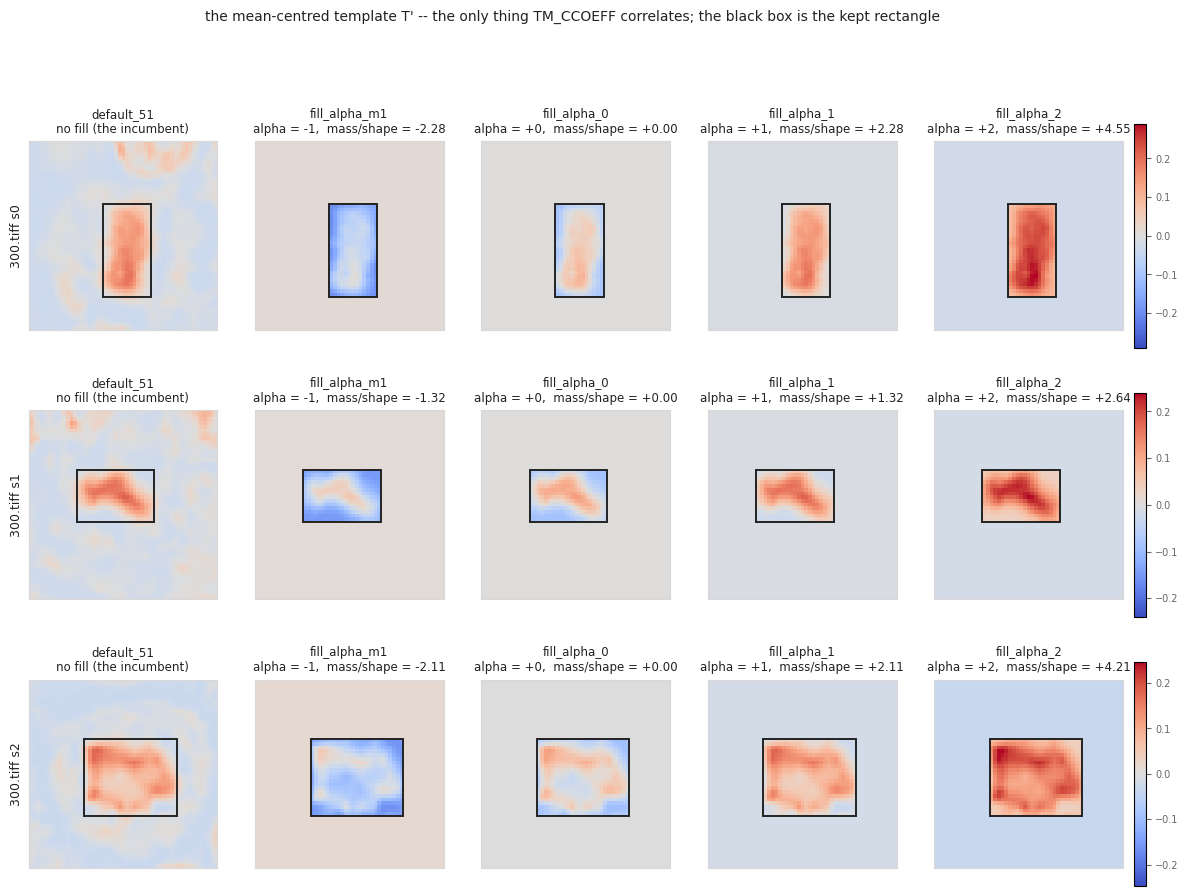

-> fillalpha_inspect_templates.png


In [15]:
INK, MUTED, GRID = '#222222', '#666666', '#d8d8d8'


def recessive(ax):
    """
        Push an axes' frame and grid behind the data, the house style for every panel here.

        ax (matplotlib.axes.Axes): the axes to restyle.

        Returns None.
    """
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=8, length=3)
    ax.grid(True, color=GRID, linewidth=0.6, alpha=0.8)
    ax.set_axisbelow(True)


# Figure 1 -- the five templates for one ROI's clicks, drawn as T' (what TM_CCOEFF actually correlates).
# T' is signed around 0, so this is a diverging scale with a neutral midpoint and symmetric limits shared across a
# row; the alpha=0 ring reads as flat midtone because its T' is exactly 0, and the alpha=-1 ring has the opposite
# sign to the alpha=1 and alpha=2 rings.
panel_clicks = [(INSPECT_ROI, s) for s in SEED_INDICES if (INSPECT_ROI, s) in CUTS] or list(CUTS)[:3]
fig, axes = plt.subplots(len(panel_clicks), len(ARMS), figsize=(2.9 * len(ARMS), 3.3 * len(panel_clicks)), squeeze=False)
for row, key in enumerate(panel_clicks):
    cut = CUTS[key]
    y0, y1, x0, x1 = cut['rect']
    primes = {arm: cut['templates'][arm].astype(np.float64) - cut['templates'][arm].astype(np.float64).mean() for arm in ARMS}
    vmax = max(float(np.abs(p).max()) for p in primes.values())
    for col, arm in enumerate(ARMS):
        ax = axes[row][col]
        im = ax.imshow(primes[arm], cmap='coolwarm', vmin=-vmax, vmax=vmax)
        ax.add_patch(Rectangle((x0 - 0.5, y0 - 0.5), x1 - x0, y1 - y0, fill=False, edgecolor=INK, linewidth=1.4))
        subtitle = 'no fill (the incumbent)' if arm == 'default_51' else f"alpha = {ARM_ALPHA[arm]:+g},  mass/shape = {cut['ratios'][arm]:+.2f}"
        ax.set_title(f'{arm}\n{subtitle}', fontsize=8.5, color=INK)
        ax.set_xticks([])
        ax.set_yticks([])
        for side in ax.spines.values():
            side.set_color(GRID)
    axes[row][0].set_ylabel(f'{key[0]} s{key[1]}', fontsize=9, color=INK)
    fig.colorbar(im, ax=axes[row], fraction=0.016, pad=0.01).ax.tick_params(colors=MUTED, labelsize=7)
fig.suptitle("the mean-centred template T' -- the only thing TM_CCOEFF correlates; the black box is the kept rectangle", fontsize=10, color=INK, y=0.995)
fig.savefig(FIG_PATHS['inspect_templates'], dpi=130, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"-> {FIG_PATHS['inspect_templates']}")

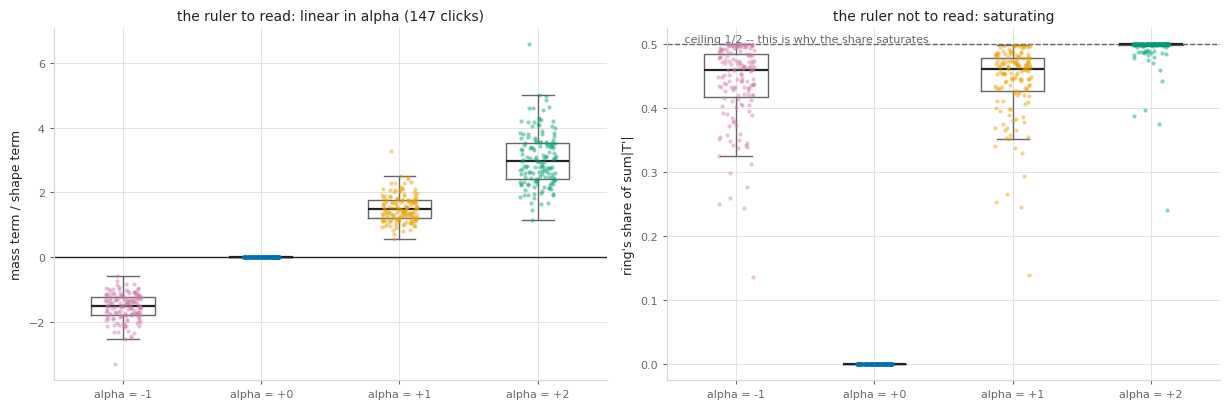

-> fillalpha_surround_weight.png


In [16]:
# Figure 2 -- the two rulers, side by side. Left: mass-to-shape, linear in alpha and unbounded, the quantity that
# says how far apart two arms are. Right: the ring's share of sum|T'|, which saturates at 1/2 and would make
# alpha = 1 and alpha = 2 look almost identical. One mark per click per arm.
fig, (ax_ms, ax_sh) = plt.subplots(1, 2, figsize=(12.4, 4.2))
jitter = np.random.default_rng(0).uniform(-0.13, 0.13, size=len(CLICK_TABLE))
for ax, prefix, label, ceiling in ((ax_ms, 'mass_to_shape', 'mass term / shape term', None), (ax_sh, 'ring_share', "ring's share of sum|T'|", 0.5)):
    for i, arm in enumerate(FILL_ARMS):
        v = CLICK_TABLE[f'{prefix}_{arm}'].to_numpy()
        ax.scatter(np.full(len(v), i) + jitter, v, s=9, color=ARM_COLOR[arm], alpha=0.45, linewidths=0, zorder=3)
        ax.boxplot([v], positions=[i], widths=0.46, showfliers=False, medianprops=dict(color=INK, linewidth=1.6), whiskerprops=dict(color=MUTED, linewidth=1.0), capprops=dict(color=MUTED, linewidth=1.0), boxprops=dict(color=MUTED, linewidth=1.0))
    if ceiling is not None:
        ax.axhline(ceiling, color=MUTED, linestyle='--', linewidth=1.0, zorder=1)
        ax.text(-0.4, ceiling, ' ceiling 1/2 -- this is why the share saturates', fontsize=8, color=MUTED, va='bottom')
    else:
        ax.axhline(0, color=INK, linewidth=1.0, zorder=2)
    ax.set_xticks(range(len(FILL_ARMS)))
    ax.set_xticklabels([f'alpha = {ARM_ALPHA[arm]:+g}' for arm in FILL_ARMS], fontsize=9, color=INK)
    ax.set_ylabel(label, fontsize=9, color=INK)
    recessive(ax)
ax_ms.set_title(f'the ruler to read: linear in alpha ({len(CLICK_TABLE)} clicks)', fontsize=10, color=INK)
ax_sh.set_title('the ruler not to read: saturating', fontsize=10, color=INK)
fig.tight_layout()
fig.savefig(FIG_PATHS['surround_weight'], dpi=130, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"-> {FIG_PATHS['surround_weight']}")

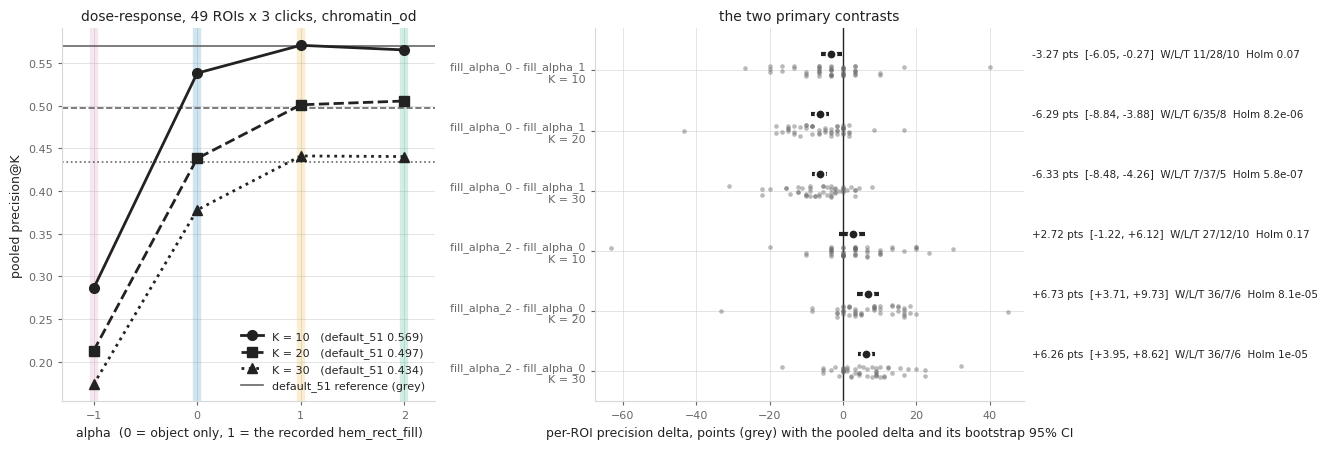

-> fillalpha_precision.png

notebook total: 37.9 min


In [17]:
# Figure 3 -- the outcome. Left: the dose-response, pooled precision against alpha with default_51 as a reference
# line per K. Right: the two primary contrasts' per-ROI deltas, with the pooled delta and its bootstrap CI.
fig, (ax_dr, ax_d) = plt.subplots(1, 2, figsize=(13.4, 4.6), gridspec_kw=dict(width_ratios=[1, 1.15]))

# The default_51 reference lines are NOT labelled in place: two budgets' pooled precisions can sit a fraction of a
# point apart, and their labels would then overlap illegibly. Each K's reference value goes in that K's legend
# entry instead, and the grey lines carry the same linestyle as their K so the pairing stays readable.
K_STYLE = {10: ('-', 'o'), 20: ('--', 's'), 30: (':', '^')}
alphas = [ARM_ALPHA[a] for a in FILL_ARMS]
for i, a in enumerate(FILL_ARMS):
    ax_dr.axvline(alphas[i], color=ARM_COLOR[a], linewidth=6, alpha=0.18, zorder=1)
for k in BUDGETS:
    style, marker = K_STYLE[k]
    v = [POOLED.loc[(POOLED['condition'] == a) & (POOLED['K'] == k), 'precision_pooled'].iat[0] for a in FILL_ARMS]
    ref = POOLED.loc[(POOLED['condition'] == 'default_51') & (POOLED['K'] == k), 'precision_pooled'].iat[0]
    ax_dr.axhline(ref, color=ARM_COLOR['default_51'], linestyle=style, linewidth=1.2, zorder=2)
    ax_dr.plot(alphas, v, style, marker=marker, ms=7, linewidth=2, color=INK, label=f'K = {k}   (default_51 {ref:.3f})', zorder=4)
ax_dr.plot([], [], '-', color=ARM_COLOR['default_51'], linewidth=1.2, label='default_51 reference (grey)')
ax_dr.set_xticks(alphas)
ax_dr.set_xlabel('alpha  (0 = object only, 1 = the recorded hem_rect_fill)', fontsize=9, color=INK)
ax_dr.set_ylabel('pooled precision@K', fontsize=9, color=INK)
ax_dr.set_xlim(alphas[0] - 0.3, alphas[-1] + 0.3)
ax_dr.set_title(f'dose-response, {N_ROIS} ROIs x 3 clicks, chromatin_od', fontsize=10, color=INK)
ax_dr.legend(fontsize=8, frameon=False, labelcolor=INK, loc='best')
recessive(ax_dr)

# The annotations are placed OUTSIDE the axes, at a fixed axes fraction, so the x-limit can be set from the data
# alone. Reserving in-axes room for them instead would let one outlying ROI stretch the scale until every
# bootstrap CI collapsed to a few pixels -- the marks that carry the result.
primary = [f'{a} - {b}' for a, b in FAMILIES['primary_6']]
rows = [(p, k) for p in primary for k in BUDGETS]
stats = {(p, k): DELTA_STATS[(DELTA_STATS['pair'] == p) & (DELTA_STATS['K'] == k)].iloc[0] for p, k in rows}
spread = [100 * v for st in stats.values() for v in (st['ci_low'], st['ci_high'])] + [100 * v for p, k in rows for v in DELTA_PER_ROI.loc[(DELTA_PER_ROI['pair'] == p) & (DELTA_PER_ROI['K'] == k), 'delta_tp_sum'] / (3 * k)]
lo, hi = min(spread), max(spread)
labels = []
for j, (pair, k) in enumerate(rows):
    v = 100 * DELTA_PER_ROI.loc[(DELTA_PER_ROI['pair'] == pair) & (DELTA_PER_ROI['K'] == k), 'delta_tp_sum'].to_numpy() / (3 * k)
    st = stats[(pair, k)]
    ax_d.scatter(v, np.full(len(v), j) + np.random.default_rng(k).uniform(-0.1, 0.1, len(v)), s=11, color=MUTED, alpha=0.45, linewidths=0, zorder=3)
    ax_d.plot([100 * st['ci_low'], 100 * st['ci_high']], [j - 0.28, j - 0.28], color=INK, linewidth=3, solid_capstyle='butt', zorder=4)
    ax_d.plot([100 * st['pooled_delta_precision']], [j - 0.28], marker='o', ms=7, color=INK, markeredgecolor='white', markeredgewidth=1.4, zorder=5)
    ax_d.annotate(f"{100 * st['pooled_delta_precision']:+.2f} pts  [{100 * st['ci_low']:+.2f}, {100 * st['ci_high']:+.2f}]  W/L/T {int(st['wins'])}/{int(st['losses'])}/{int(st['ties'])}  Holm {st['holm_p']:.2g}", xy=(1.02, j - 0.28), xycoords=('axes fraction', 'data'), fontsize=7.5, color=INK, va='center', ha='left', annotation_clip=False)
    labels.append(f'{pair}\nK = {k}')
ax_d.axvline(0, color=INK, linewidth=1.0, zorder=2)
ax_d.set_xlim(lo - 0.04 * (hi - lo), hi + 0.04 * (hi - lo))
ax_d.set_yticks(range(len(labels)))
ax_d.set_yticklabels(labels, fontsize=7.5, color=INK)
ax_d.set_xlabel('per-ROI precision delta, points (grey) with the pooled delta and its bootstrap 95% CI', fontsize=9, color=INK)
ax_d.set_title('the two primary contrasts', fontsize=10, color=INK)
ax_d.set_ylim(len(labels) - 0.5, -0.7)
recessive(ax_d)

fig.tight_layout()
fig.savefig(FIG_PATHS['precision'], dpi=130, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"-> {FIG_PATHS['precision']}")
print(f'\nnotebook total: {(time.time() - NB_T0) / 60:.1f} min')

## Reading the result

**Outcome: precision rises with `alpha` and then saturates.** This is the third pre-registered outcome --
*"the isolation prior is doing real work and the original hypothesis holds"* -- with one refinement the header did
not anticipate: the rise happens entirely between `alpha = 0` and `alpha = 1`, and is flat from `alpha = 1` to
`alpha = 2`. It is **not** the peak-at-zero case, and it is not linear either.

Pooled precision@K (K = 10 / 20 / 30), 49 ROIs x 3 clicks, `chromatin_od`:

| arm | `alpha` | K=10 | K=20 | K=30 |
|---|---|---|---|---|
| `fill_alpha_m1` | -1 | 0.2857 | 0.2126 | 0.1732 |
| `fill_alpha_0` | 0 | 0.5381 | 0.4381 | 0.3778 |
| `fill_alpha_1` | 1 | **0.5707** | **0.5010** | **0.4410** |
| `fill_alpha_2` | 2 | 0.5653 | 0.5054 | 0.4404 |
| `default_51` | -- | 0.5694 | 0.4973 | 0.4340 |

### The verdicts

**`fill_alpha_0 - fill_alpha_1` is negative and resolves at K = 20 and 30.** Making the ring weightless -- the
"object only" template -- **costs** precision against the recorded fill.
- K=10: -3.27 pts, bootstrap [-6.05, -0.27], t [-6.26, -0.27], W/L/T 11/28/10, 39 nonzero, exact p 0.035,
  Holm 0.070, D5 bar **met**.
- K=20: -6.29 pts, bootstrap [-8.84, -3.88], t [-8.85, -3.74], W/L/T 6/35/8, 41 nonzero, exact p 1.6e-06,
  Holm 8.2e-06, D5 bar **met**.
- K=30: -6.33 pts, bootstrap [-8.48, -4.26], t [-8.53, -4.13], W/L/T 7/37/5, 44 nonzero, exact p 9.6e-08,
  Holm 5.8e-07, D5 bar **met**.

**`fill_alpha_2 - fill_alpha_0` is positive and resolves at K = 20 and 30**, the same effect seen from the other
end: +6.73 pts [+3.71, +9.73] (t [+3.64, +9.83], 36/7/6, Holm 8.1e-05, D5 met) at K=20 and +6.26 pts
[+3.95, +8.62] (t [+3.81, +8.71], 36/7/6, Holm 1.0e-05, D5 met) at K=30. At K=10 it does not resolve: +2.72 pts
[-1.22, +6.12], Holm 0.171, D5 not met.

**`fill_alpha_2 - fill_alpha_1` resolves nothing, with tight bounds.** -0.54 pts [-1.77, +0.41] at K=10,
+0.44 [-0.58, +1.33] at K=20, -0.07 [-0.75, +0.52] at K=30; every Holm p is 1.0 and D5 is never met. Doubling the
mass term beyond the recorded fill changes precision by less than about 1.8 points in either direction. **This is
where the dial saturates.**

**Both `fill_alpha_1` and `fill_alpha_2` sit on `default_51`.** `fill_alpha_1 - default_51` is +0.14 / +0.37 /
+0.70 pts with every CI straddling 0 (Holm 1.0 throughout); `fill_alpha_2 - default_51` likewise. So the arms that
keep a mass term are indistinguishable from the untouched 51 px window.

**`fill_alpha_0 - default_51` is negative**: -3.13 pts [-6.12, +0.07] at K=10 (Holm 0.41, D5 not met), -5.92
[-8.57, -3.40] at K=20 (Holm 1.2e-04, D5 met), -5.62 [-7.80, -3.54] at K=30 (Holm 1.5e-05, D5 met).

**The tested trend over `alpha = (0, 1, 2)` is positive and resolves at K = 20 and 30**: +2.02 TP per ROI per unit
alpha [+1.11, +2.92] (Holm 5.4e-05) at K=20 and +2.82 [+1.78, +3.88] (Holm 7.5e-06) at K=30; at K=10 it does not
(+0.41 [-0.18, +0.92], Holm 0.171). Read it together with the saturation above: the trend is driven by the
`alpha = 0` to `alpha = 1` step, not by a steady climb.

**The anchor did its job.** `fill_alpha_m1` loses 26-28 points against every other arm (all Holm <= 1.4e-12,
45-48 of 49 ROIs) and shares a median of **0** top-30 detections with `fill_alpha_1`. The measurement plainly has
leverage over the fill value, so the `alpha_2 - alpha_1` null is a real flat region rather than an insensitive
design. `fill_alpha_0` vs `fill_alpha_1` share a median of only **2 of 30** top-30 detections -- the two arms the
primary question is about are almost entirely different detectors, which is what makes their 6-point gap
meaningful rather than marginal.

### What this means

The premise this notebook was built to test -- that `fill = mean(outside)` was the wrong value because it leaves
the ring carrying weight -- **is wrong as a recommendation**. The algebra behind it holds exactly (Gate 6), but the
weight it identified is load-bearing: removing it costs 6 points at K = 20/30. Read together with the recorded
`hem_rect_fill - default_51` null, the picture is:

- the surround's **structure** does not matter (`alpha = 1` sits on `default_51`);
- the surround's **aggregate mass term** matters a great deal (`alpha = 0` loses 6 points);
- and once any mass term is present, more of it adds nothing (`alpha = 2` equals `alpha = 1`).

"Flatten the surround to something background-like" was the right instinct. "Make the ring contribute nothing" is
not.

### The confound this cannot separate

The header pre-registered this for large `alpha`, and it now bears on the main result. The mass term is
`sum_kept(I')` -- integrated OD inside the kept footprint -- and the ranking axis is `chromatin_od`, integrated OD
over a 51 px window. So an arm with a mass term generates candidates that are pre-aligned with the axis they are
then ranked on, and part of the `alpha = 0` deficit may be that `alpha = 0` alone is **not** so aligned, rather
than that its template is worse.

The saturation argues against alignment being the whole story: if it were, doubling the mass term at `alpha = 2`
should have kept helping, and it does not (every CI straddles 0). But this design cannot decide the question. The
clean test would repeat it at `rank_key="tm_score"`, where generation and ranking share no axis. **Do not quote the
6-point gap as "the object-only template is a worse detector" without that.**

### Standing caveats

- `chromatin_od` ranking only, on the 147 clicks the 49-ROI joint gate selected, so every click is one where both
  Otsu gates accept.
- Four points on the dial and one keep-region (the tight `tighten_box_otsu` rectangle).
- `alpha`'s effective weight is `alpha * (m_kept - m_outside)` and varies per click: the mass-to-shape ratio at
  `alpha = 1` has median 1.49 (IQR 1.21-1.76) over the 147 clicks. Read that ratio, not the ring's share of
  `sum|T'|`, which saturates near 1/2 by construction.
- `max_peaks` binds at 100 on 735/735 runs, so every arm is compared at a saturated pool.
- `seed_annulus_empty` fails on 8 runs, **all** of them `fill_alpha_m1`: the inverted template puts detections
  inside one match radius of the click, which no other arm does. It does not affect any verdict above, since
  `fill_alpha_m1` is an anchor, but it is another sign that arm is not a detector anyone would ship.
- `fill_alpha_1 - default_51` here is a post-D11 re-measurement of the recorded pre-D11 delta (+0.14 / +0.37 /
  +0.70 against the recorded +0.20 / +0.48 / +0.93). They are not independent estimates of one quantity; the gap is
  D11. Both are in `..._d11_remeasurement.csv`.
- Nothing here speaks to the keep-region's **shape**. But note the implication for that direction: template
  sensitivity is concentrated in whether a mass term exists at all, not in where the rectangle's edge sits --
  which is consistent with the 1 um margin resolving flat, and makes a 1-2 px change to the rectangle an
  unpromising lever.